#   LABORATORIO Nº 1

## Alumnos:
- Araujo, Facundo
- Damaria, Leonel
- Orozco, Lucas
- Varas, María
- Yohena Tanoni, Brenda



## Importación de Librerías

In [114]:
%pip install matplotlib seaborn plotly scipy
%pip install prettytable
%pip install joypy


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade nbformat


Note: you may need to restart the kernel to use updated packages.


* Esto de acá lo tuve que resolver con copilot, porque no podía cargar matplotlib

In [115]:
import sys
print(sys.executable)

c:\Users\Brenda\.anaconda-desktop\micromamba\envs\assistant\python.exe


In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import joypy
import seaborn as sns
#
import plotly.express as px
import plotly.graph_objects as go
# Para importación de archivos y acceso a rutas. De apunte de Python
import glob
import os
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px

from itertools import combinations
from collections import Counter

## Carga de Datos y Creacion de Dataframe Original

In [5]:
# Creacion de Ruta a la Carpeta del Dataset
path_dataset = "Dataset de ventas/*.csv"

# Listar Archivos
file_list = glob.glob(path_dataset)

# Leer y concatenar los archivos
read_file = [pd.read_csv(f) for f in file_list]
original_df = pd.concat(read_file, ignore_index=True)

print(f"Archivos encontrados: {len(file_list)}")

for archivo in file_list:
    temp = pd.read_csv(archivo)
    print(os.path.basename(archivo), temp.shape)

original_df.head()


Archivos encontrados: 12
Dataset_de_ventas_Abril.csv (18383, 6)
Dataset_de_ventas_Agosto.csv (12011, 6)
Dataset_de_ventas_Diciembre.csv (25117, 6)
Dataset_de_ventas_Enero.csv (9723, 6)
Dataset_de_ventas_Febrero.csv (12036, 6)
Dataset_de_ventas_Julio.csv (14371, 6)
Dataset_de_ventas_Junio.csv (13622, 6)
Dataset_de_ventas_Marzo.csv (15226, 6)
Dataset_de_ventas_Mayo.csv (16635, 6)
Dataset_de_ventas_Noviembre.csv (17661, 6)
Dataset_de_ventas_Octubre.csv (20379, 6)
Dataset_de_ventas_Septiembre.csv (11686, 6)


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


### Aclaración: desde este momento, se va trabajar con copia del dataframe original para proteger la conservación de datos

In [6]:
df = original_df.copy(deep=True)
df.info

<bound method DataFrame.info of        ID de Pedido                    Producto Cantidad Pedida  \
0            176558        USB-C Charging Cable               2   
1               NaN                         NaN             NaN   
2            176559  Bose SoundSport Headphones               1   
3            176560                Google Phone               1   
4            176560            Wired Headphones               1   
...             ...                         ...             ...   
186845       259353      AAA Batteries (4-pack)               3   
186846       259354                      iPhone               1   
186847       259355                      iPhone               1   
186848       259356      34in Ultrawide Monitor               1   
186849       259357        USB-C Charging Cable               1   

       Precio Unitario Fecha de Pedido  \
0                11.95  04/19/19 08:46   
1                  NaN             NaN   
2                99.99  04/07/19 22:3

## Limpieza de datos
- Eliminar datos no numéricos.
- Eliminar filas incompletas

Se realizó una evaluación de la naturaleza de los datos cargados en el dataframe

 | **[id](ca://s?q=id)** | **[ID Pedido](ca://s?q=ID_Pedido)** | **[Producto](ca://s?q=Producto)** | **[Cantidad Pedida](ca://s?q=Cantidad_Pedida)** | **[Precio Unitario](ca://s?q=Precio_Unitario)** | **[Fecha Pedido](ca://s?q=Fecha_Pedido)** | **[Dirección](ca://s?q=Direccion)** |
|-----------------------|--------------------------------------|-----------------------------------|-----------------------------------------------|-----------------------------------------------|----------------------------------------------|----------------------------------------------|
| **[num](ca://s?q=num)** | **[num](ca://s?q=num)** | **[string](ca://s?q=string)** | **[num](ca://s?q=num)** | **[num](ca://s?q=num)** | **[num](ca://s?q=num)** | **[string](ca://s?q=string)** |


 Hay 7 columnas, de las cuales:

 - 3 tienen valores tipo string (nombre del producto, dirección, fecha)
 - 4 tiene valores tipo numérico (id, id pedido, cantidad pedida, precio).

 Si hay al realizar la limpieza de datos, eliminamos todos los numéricos, terminaríamos sin datos. Por lo que vamos a eliminar los datos no numericos solo de las tablas numéricas, y luego eliminaremos las filas incompletas del resto del dataframe.


In [ ]:
print(" El dataframe original:") 
df.head(3)
print("La cantidad original de filas en el dataframe:", df.shape[0])
print(df.isnull().sum())
print(" Se eliminan valores no numéricos de las columnas Id de pedido, cantidad pedida, precio unitario")
col_num = ["ID de Pedido", "Cantidad Pedida", "Precio Unitario"]
df[col_num] = df[col_num].apply(pd.to_numeric, errors='coerce')
print("Nulos luego de convertir valores no numericos:")
print(df.isnull().sum())
print("Filas antes de la limpieza:", df.shape[0])
df = df.dropna()
print("Limpiando ...")
print("Filas luego de limpieza:", df.shape[0])

df.head()

 El dataframe original:
La cantidad original de filas en el dataframe: 186850
ID de Pedido          545
Producto              545
Cantidad Pedida       545
Precio Unitario       545
Fecha de Pedido       545
Dirección de Envio    545
dtype: int64
 Se eliminan valores no numéricos de las columnas Id de pedido, cantidad pedida, precio unitario
Nulos luego de convertir valores no numericos:
ID de Pedido          900
Producto              545
Cantidad Pedida       900
Precio Unitario       900
Fecha de Pedido       545
Dirección de Envio    545
dtype: int64
Filas antes de la limpieza: 186850
Limpiando ...
Filas luego de limpieza: 185950


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558.0,USB-C Charging Cable,2.0,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559.0,Bose SoundSport Headphones,1.0,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560.0,Google Phone,1.0,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560.0,Wired Headphones,1.0,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561.0,Wired Headphones,1.0,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


### Ajustar los tipos de datos de cada atributo

Para ajustar datos, comenzamos de izquierda a derecha según las columnas.
1. ID Pedido: se lo convierte a número entero y luego en String. No va a ser necesario realizar operaciones entre los números de ID del pedido.

In [8]:
df['ID de Pedido'] = df['ID de Pedido'].astype(int).astype(str)
df.head(2)

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2.0,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1.0,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"


2. Cantidad Pedida: se ajusta el resultado a valores enteros. Al ser elementos tecnoólgicos, no se venden por fracciones.

In [9]:
df['Cantidad Pedida'] = df['Cantidad Pedida'].astype(int)
df.head(2)

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"


3. Precio Unitario: nos aseguramos que sea  un valor numérico decimal

In [10]:
df['Precio Unitario'] = df['Precio Unitario'].astype(float)

4. Fecha de Pedido: se ajusta a valores tipo datetime para poder realizar analisis de fechas y horarios de mayores ventas

In [11]:
df['Fecha de Pedido'] = pd.to_datetime(df['Fecha de Pedido'])
df.head(2)

C:\Users\Brenda\AppData\Local\Temp\ipykernel_26188\579378820.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha de Pedido'] = pd.to_datetime(df['Fecha de Pedido'])


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215"


### Extraer características importantes para el análisis como meses, horas, ciudades etc.
Se extraen las características más importantes para poder mejorar la interpretación de los resultados. Al separar más claramente los meses, la hora de la compra, y sucursal; podremos obtener mapas de calor de ventas de ubicación y hora de ventas.

Uso de map, ayuda con:
https://www.youtube.com/watch?v=tnVRfu8gVj8

In [12]:
## Constantes 

# Mapeo de nombres de días de inglés a español
DIAS_ES = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

# Lista ordenada de nombres de meses en español
MESES_NOMBRES = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

In [13]:
## Extracción de Características de Fecha y Ubicación 

# Extracción de Mes (numérico)
df['Mes'] = df['Fecha de Pedido'].dt.month

# Extracción de Día del mes
df['Dia'] = df['Fecha de Pedido'].dt.day

# Extracción del Día de la Semana usamos el diccionario DIAS_ES para mapearlo 
df["dia_semana"] = df["Fecha de Pedido"].dt.day_name().map(DIAS_ES)

# Extracción de la Hora
df['Hora'] = df['Fecha de Pedido'].dt.hour

# Extracción de la Ciudad desde la dirección de envío
df['Ciudad'] = df['Dirección de Envio'].apply(lambda x: x.split(',')[1].strip())

# Cálculo de la Venta (Cantidad * Precio)
df['Venta'] = df['Cantidad Pedida'] * df['Precio Unitario']

# Verificamos el resultado final
print("Días de la semana únicos en el dataframe:")
print(df['dia_semana'].unique())

print("\nCiudades únicas extraídas:")
print(df['Ciudad'].unique())

df.head()

Días de la semana únicos en el dataframe:
<StringArray>
['Viernes', 'Domingo', 'Martes', 'Lunes', 'Miércoles', 'Jueves', 'Sábado']
Length: 7, dtype: str

Ciudades únicas extraídas:
<StringArray>
[       'Dallas',        'Boston',   'Los Angeles', 'San Francisco',
       'Seattle',       'Atlanta', 'New York City',      'Portland',
        'Austin']
Length: 9, dtype: str


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio,Mes,Dia,dia_semana,Hora,Ciudad,Venta
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,19,Viernes,8,Dallas,23.90
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,7,Domingo,22,Boston,99.99
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,Viernes,14,Los Angeles,600.00
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,Viernes,14,Los Angeles,11.99
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,Martes,9,Los Angeles,11.99


## Análisis de Datos

Ejemplo:
- Examinar las horas del día en que las ventas son más frecuentes.
- Determinar el mejor momento para mostrar publicidad.

### Para detalles de redacción de documentación:
- Obtenemos las fechas del dataframe

In [127]:
fecha_min = df['Fecha de Pedido'].min()
fecha_max = df['Fecha de Pedido'].max()

print(f"Fecha más antigua: {fecha_min}")
print(f"Fecha más reciente: {fecha_max}")
print(f"Período total: desde {fecha_min.date()} hasta {fecha_max.date()}")

Fecha más antigua: 2019-01-01 03:07:00
Fecha más reciente: 2020-01-01 05:13:00
Período total: desde 2019-01-01 hasta 2020-01-01


## Oferta y demanda
Para entender parte del sistema de oferta y  de los productos de la empresa evaluamos si los productos varian de precio a lo largo del año.
https://www.investopedia.com/terms/l/law-of-supply-demand.asp

### OFERTA

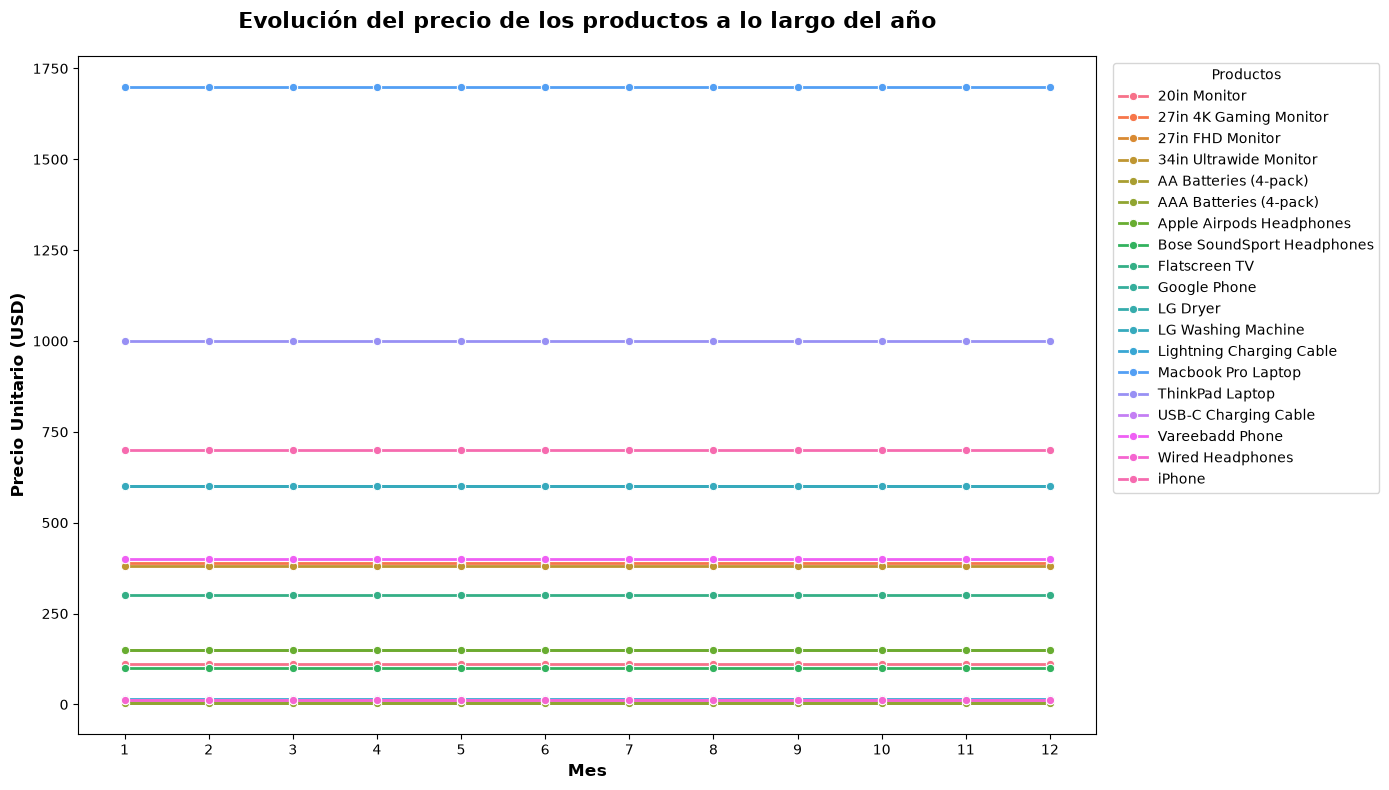

In [14]:

precio_evolucion = df.groupby(['Mes', 'Producto'])['Precio Unitario'].mean().reset_index()

# Gráfico 1
plt.figure(figsize=(14, 8))

# Gráfico de líneas
sns.lineplot(
    data=precio_evolucion,
    x='Mes',
    y='Precio Unitario',
    hue='Producto',  
    marker='o',      
    linewidth=2
)


plt.title('Evolución del precio de los productos a lo largo del año', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12, fontweight='bold')
plt.ylabel('Precio Unitario (USD)', fontsize=12, fontweight='bold')


plt.xticks(range(1, 13))


plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Productos')

plt.tight_layout()
plt.show()

### Precio Promedio

In [141]:
df_mes_producto = df.groupby(['Mes', 'Producto']).agg(
    Precio_Promedio=('Precio Unitario', 'mean'),
    Unidades_Vendidas=('Cantidad Pedida', 'sum'),
    Ventas=('Venta', 'sum')
).reset_index()

# Precio promedio por mes
precio_simple = df_mes_producto.groupby('Mes')['Precio_Promedio'].mean()
print(precio_simple)

Mes
1     380.297895
2     380.297895
3     380.297895
4     380.297895
5     380.297895
6     380.297895
7     380.297895
8     380.297895
9     380.297895
10    380.297895
11    380.297895
12    380.297895
Name: Precio_Promedio, dtype: float64


No hay cambio en la oferta de los productos vendidos.

### DEMANDA

### Ventas por mes
Es importante saber si los productos siguen las leyes de mercado, o presentan fluctuaciones estacionales.

In [15]:
meses_mas_ventas = df.groupby('Mes')['Venta'].sum().sort_values(ascending=False)
print("los meses con mas ventas: ", meses_mas_ventas)

los meses con mas ventas:  Mes
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Venta, dtype: float64


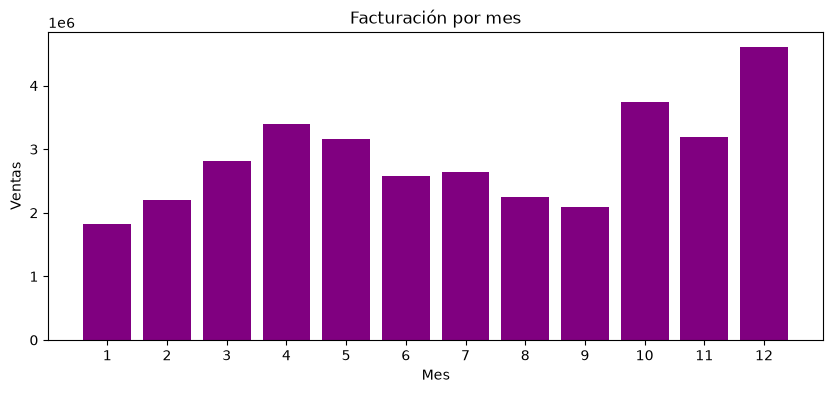

In [16]:
# Grafico 1 de Facturación
plt.figure(figsize=(10,4))
plt.bar(meses_mas_ventas.index, meses_mas_ventas.values, color="purple")
plt.title("Facturación por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(meses_mas_ventas.index)
plt.show()

### Opción barras verticales

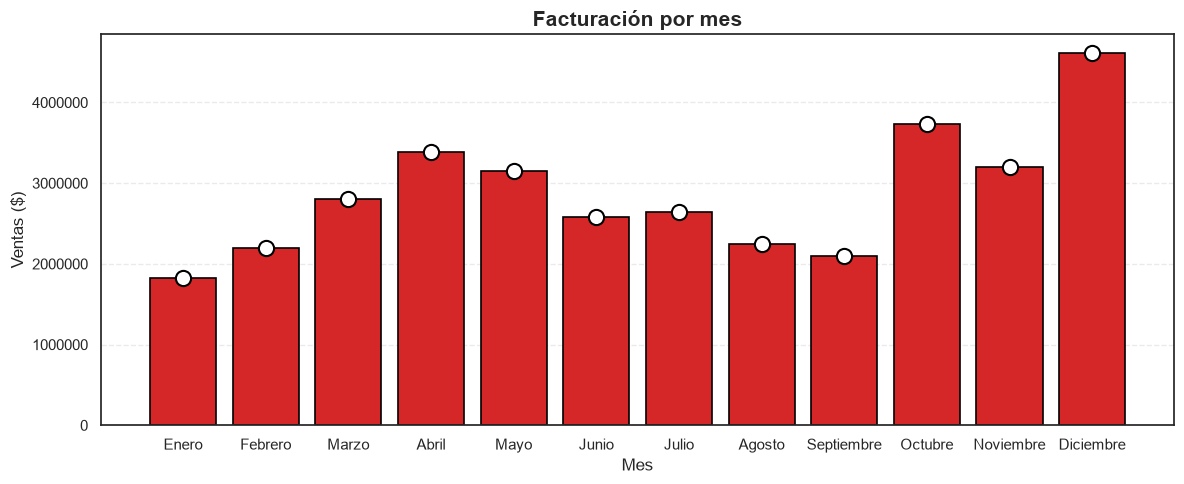

In [46]:

ventas_ordenadas = meses_mas_ventas.sort_index()

plt.figure(figsize=(12, 5))


x = ventas_ordenadas.index
y = ventas_ordenadas.values


plt.bar(x, y, color="#d62728", edgecolor="black", linewidth=1.2)
plt.scatter(x, y, color="white", s=120, edgecolor="black", linewidth=1.5, zorder=3)

plt.title("Facturación por mes", fontsize=15, fontweight="bold")
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ventas ($)", fontsize=12)
plt.xticks(x, meses_nombres)


plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Opción barras horizontales

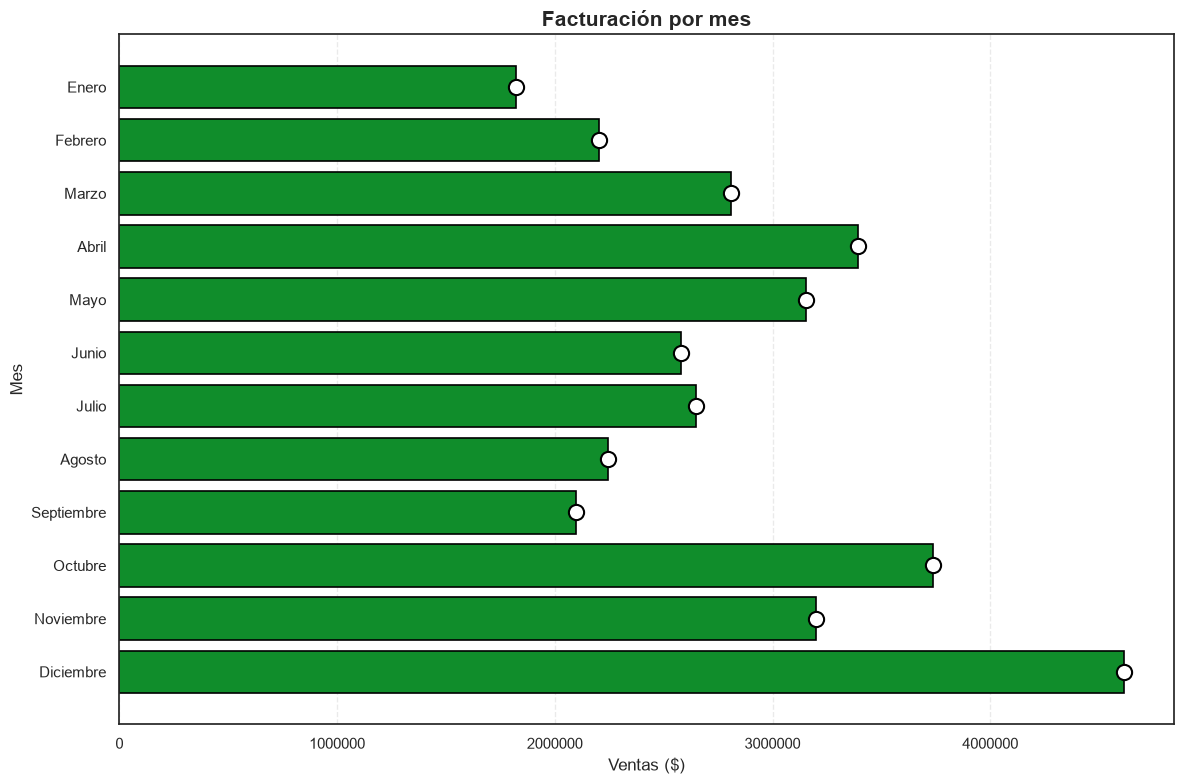

In [47]:

ventas_ordenadas = meses_mas_ventas.sort_index()

plt.figure(figsize=(12, 8)) 


y = ventas_ordenadas.index
x = ventas_ordenadas.values


plt.barh(y, x, color="#108D2B", edgecolor="black", linewidth=1.2)
plt.scatter(x, y, color="white", s=120, edgecolor="black", linewidth=1.5, zorder=3)

# Invertir eje para que enero quede arriba
plt.gca().invert_yaxis()

plt.title("Facturación por mes", fontsize=15, fontweight="bold")
plt.xlabel("Ventas ($)", fontsize=12)
plt.ylabel("Mes", fontsize=12)


plt.yticks(y, meses_nombres)

plt.ticklabel_format(style='plain', axis='x')


plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


### opcion scatter

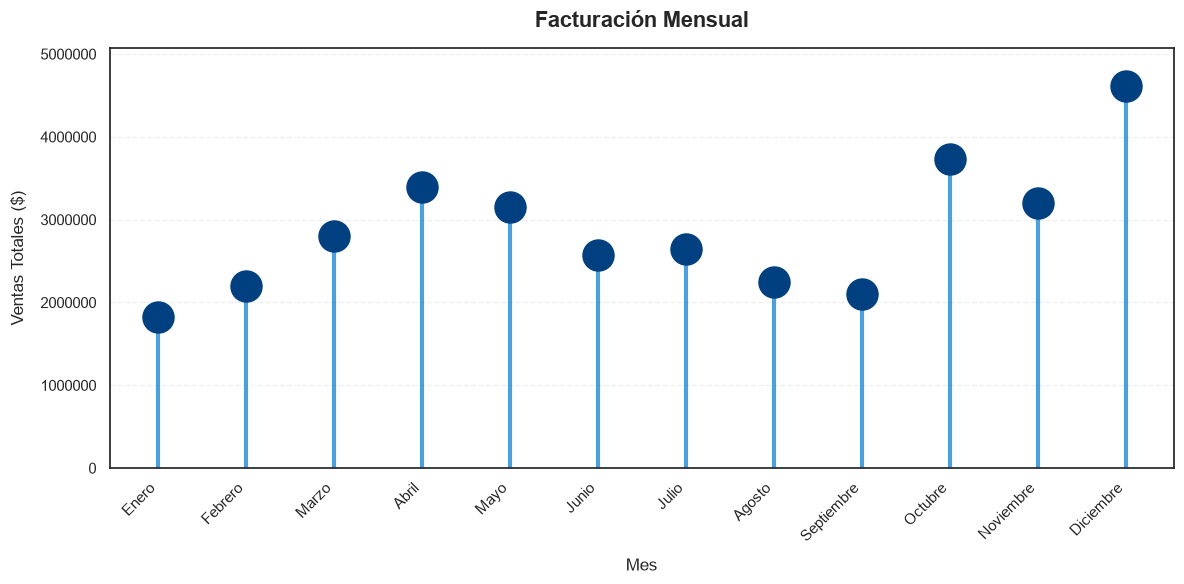

In [48]:
ventas_ordenadas = meses_mas_ventas.sort_index()

x = ventas_ordenadas.index
y = ventas_ordenadas.values

plt.figure(figsize=(12, 6))
plt.vlines(x=x, ymin=0, ymax=y, color='#007ACC', alpha=0.7, linewidth=3)
plt.scatter(x, y, s=500, color='#004080', zorder=3)

plt.title("Facturación Mensual", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Mes", fontsize=12, labelpad=10)
plt.ylabel("Ventas Totales ($)", fontsize=12, labelpad=10)

plt.xticks(x, meses_nombres, rotation=45, ha='right')


plt.ticklabel_format(style='plain', axis='y')

plt.ylim(0, max(y) * 1.1)


plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Oferta y Demanda

### Solo los méses con más ventas

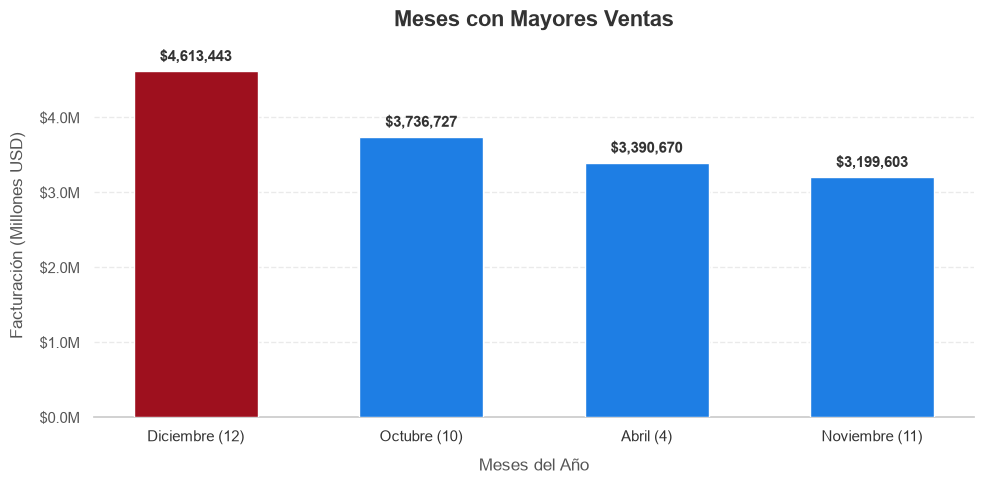

In [49]:

# 1. Diccionario de mapeo directo
meses_nombres = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
    7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

# Asignamos el nombre del mes directamente en el DataFrame para facilitar lecturas
df['Mes_Nombre'] = df['Mes'].map(meses_nombres)

# los 4 meses más altos

top_4_meses = df.groupby(['Mes', 'Mes_Nombre'])['Venta'].sum().reset_index()
top_4_meses = top_4_meses.sort_values(by='Venta', ascending=False).head(4)


valores = top_4_meses['Venta'].tolist()

meses = [f"{nombre} ({num})" for nombre, num in zip(top_4_meses['Mes_Nombre'], top_4_meses['Mes'])]

# Figura
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#FFFFFF')
ax.set_facecolor('#FFFFFF')

# Paleta de colores 

colores = ["#9E101E"] + ['#1E7EE4'] * (len(valores) - 1)

barras = ax.bar(meses, valores, color=colores, width=0.55, zorder=3)

# Formato del eje Y a millones
formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

# Estilos y títulos
ax.set_title('Meses con Mayores Ventas', fontsize=16, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Meses del Año', fontsize=12, labelpad=10, color='#555555')
ax.set_ylabel('Facturación (Millones USD)', fontsize=12, labelpad=10, color='#555555')

# Limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)

# Etiquetas de datos automatizadas sobre cada barra
for barra in barras:
    alto = barra.get_height()
    ax.annotate(f'${alto:,.0f}',
                xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5),  
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#333333')

# Ajustes finales
plt.xticks(fontsize=11, color='#333333')
plt.yticks(fontsize=11, color='#555555')
plt.tight_layout()
plt.show()

### Oferta y Demanda

In [142]:

precio_evolucion = df.groupby(['Mes', 'Producto'])['Precio Unitario'].mean().reset_index()


precio_simple = df_mes_producto.groupby('Mes')['Precio_Promedio'].mean()


meses_mas_ventas = df.groupby('Mes')['Venta'].sum().sort_values(ascending=False)
ventas_por_mes = meses_mas_ventas.sort_index()  # ← Solo reordenamos por mes 1→12

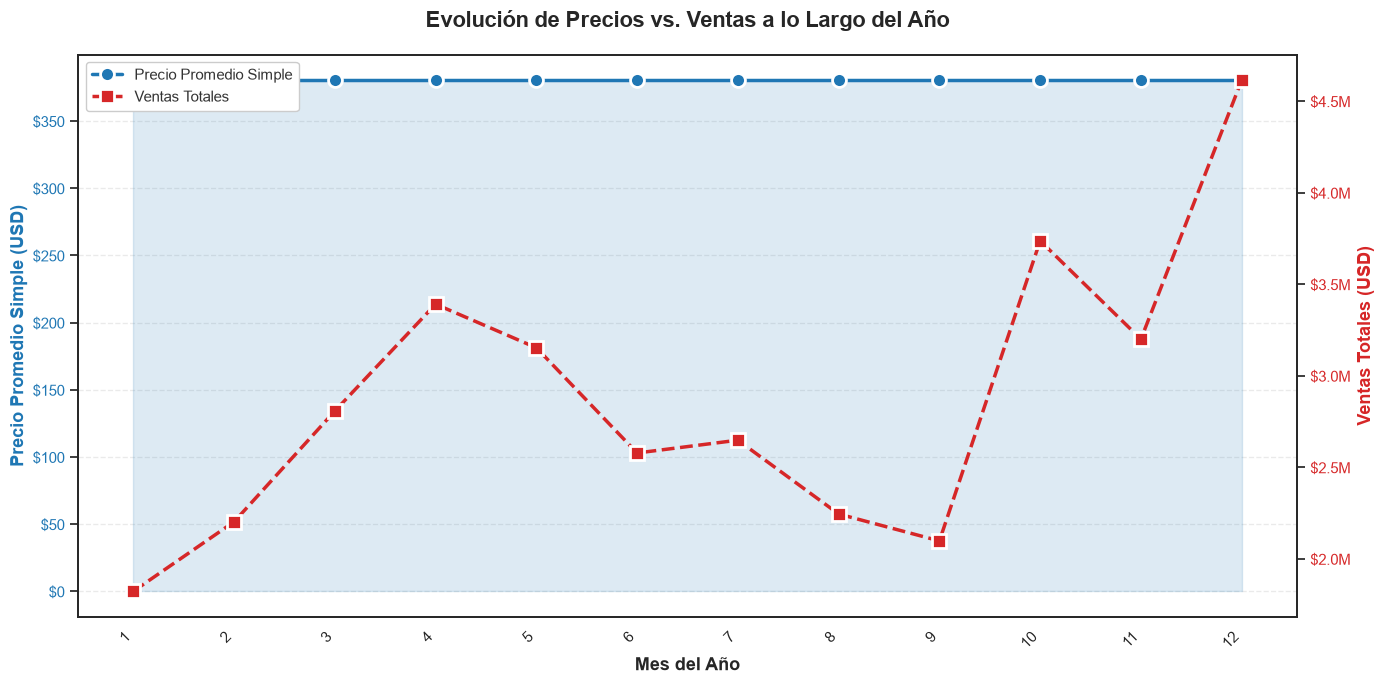

In [151]:

fig, ax1 = plt.subplots(figsize=(14, 7))


color_precio = '#1f77b4'

linea_precio, = ax1.plot(
    precio_simple.index,
    precio_simple.values,
    color=color_precio,
    marker='o',
    markersize=10,
    linewidth=2.5,
    linestyle='-',
    label='Precio Promedio Simple',
    markeredgecolor='white',
    markeredgewidth=2,
    zorder=3
)


ax1.fill_between(
    precio_simple.index,
    precio_simple.values,
    alpha=0.15,
    color=color_precio,
    zorder=2
)

ax1.set_xlabel('Mes del Año', fontsize=13, fontweight='bold')
ax1.set_ylabel('Precio Promedio Simple (USD)', color=color_precio,
               fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_precio, labelsize=11)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(meses_nombres, rotation=45, ha='right', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, p: f'${v:,.0f}'))


ax2 = ax1.twinx()
color_ventas = '#d62728'

linea_ventas, = ax2.plot(
    ventas_por_mes.index,
    ventas_por_mes.values,
    color=color_ventas,
    marker='s',
    markersize=10,
    linewidth=2.5,
    linestyle='--',
    label='Ventas Totales',
    markeredgecolor='white',
    markeredgewidth=2,
    zorder=3
)

ax2.set_ylabel('Ventas Totales (USD)', color=color_ventas,
               fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_ventas, labelsize=11)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, p: f'${v/1e6:.1f}M'))


plt.title(
    'Evolución de Precios vs. Ventas a lo Largo del Año',
    fontsize=16, fontweight='bold', pad=20
)

ax1.legend(
    [linea_precio, linea_ventas],
    ['Precio Promedio Simple', 'Ventas Totales'],
    loc='upper left',
    fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='#CCCCCC',
    framealpha=1.0,
    labelcolor='#333333'
)

ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

In [152]:
# Agrupamos por mes para calcular los KPIs
df_mes = df.groupby('Mes').agg(
    unidades_vendidas=('Cantidad Pedida', 'sum'),
    ingresos_totales=('Venta', 'sum'),
    precio_promedio=('Precio Unitario', 'mean')
).reset_index()

# Precio promedio ponderado (más representativo del ingreso real)
df_mes['precio_promedio_ponderado'] = df_mes['ingresos_totales'] / df_mes['unidades_vendidas']

# 

df_mes['Mes_Nombre'] = df_mes['Mes'].apply(lambda m: MESES_NOMBRES[m - 1])

print(df_mes)

    Mes  unidades_vendidas  ingresos_totales  precio_promedio  \
0     1              10903        1822256.73       186.607105   
1     2              13449        2202022.42       182.787868   
2     3              17005        2807100.38       184.201665   
3     4              20558        3390670.24       184.237158   
4     5              18667        3152606.75       189.250581   
5     6              15253        2577802.26       189.023580   
6     7              16072        2647775.76       184.183835   
7     8              13448        2244467.88       186.468140   
8     9              13109        2097560.13       179.415893   
9    10              22703        3736726.88       183.194696   
10   11              19798        3199603.20       180.993608   
11   12              28114        4613443.34       183.654155   

    precio_promedio_ponderado  Mes_Nombre  
0                  167.133516       Enero  
1                  163.731312     Febrero  
2                  165

In [156]:


fig = make_subplots(specs=[[{"secondary_y": True}]])

#  Barras para la Demanda (Unidades Vendidas) 
fig.add_trace(
    go.Bar(
        x=df_mes['Mes_Nombre'],
        y=df_mes['unidades_vendidas'],
        name='Demanda (Unidades Vendidas)',
        marker_color='#1f77b4',
        opacity=0.8,
        hovertemplate='<b>Mes:</b> %{x}<br>' +
                      '<b>Unidades Vendidas:</b> %{y:,.0f}<br>' +
                      '<b>Ingresos:</b> $%{customdata[0]:,.0f}<br>' +
                      '<b>Precio Prom. Ponderado:</b> $%{customdata[1]:.2f}<extra></extra>',
        customdata=df_mes[['ingresos_totales', 'precio_promedio_ponderado']]
    ),
    secondary_y=False,
)

# Línea para el Precio Promedio Ponderado 
fig.add_trace(
    go.Scatter(
        x=df_mes['Mes_Nombre'],
        y=df_mes['precio_promedio_ponderado'],
        name='Precio Promedio Ponderado',
        mode='lines+markers',
        line=dict(color='#d62728', width=3),
        marker=dict(size=10, symbol='circle', line=dict(width=2, color='white')),
        hovertemplate='<b>Mes:</b> %{x}<br>' +
                      '<b>Precio Promedio:</b> $%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)



# --- Configuración del Layout ---
fig.update_layout(
    title={
        'text': 'Análisis de Oferta y Demanda por Mes',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'color': '#333'}
    },
    xaxis=dict(
        title='Mes del Año',
        categoryorder='array',
        categoryarray=MESES_NOMBRES,  
        title_font=dict(size=14, color='#555'),
        tickfont=dict(color='#333')
    ),
    legend=dict(
        orientation="h", yanchor="bottom", y=1.02,
        xanchor="right", x=1
    ),
    plot_bgcolor='#f9f9f9',
    hovermode='x unified'
)

# --- Configuración de los Ejes Y ---
fig.update_yaxes(
    title_text="<b>Demanda (Unidades Vendidas)</b>",
    title_font=dict(color='#1f77b4', size=14),
    tickfont=dict(color='#1f77b4'),
    secondary_y=False,
    gridcolor='#e0e0e0'
)

fig.update_yaxes(
    title_text="<b>Precio Promedio ($)</b>",
    title_font=dict(color='#d62728', size=14),
    tickfont=dict(color='#d62728'),
    secondary_y=True,
    showgrid=False
)

fig.show()

In [150]:
df_hora = df.groupby('Hora').agg(
    unidades_vendidas=('Cantidad Pedida', 'sum'),
    ingresos_totales=('Venta', 'sum'),
    precio_promedio=('Precio Unitario', 'mean') # Precio promedio simple
).reset_index()


df_hora['precio_promedio_ponderado'] = df_hora['ingresos_totales'] / df_hora['unidades_vendidas']

print(df_hora)

    Hora  unidades_vendidas  ingresos_totales  precio_promedio  \
0      0               4428         713721.27       181.405806   
1      1               2619         460866.88       195.102128   
2      2               1398         234851.44       188.120386   
3      3                928         145757.89       174.159350   
4      4                937         162661.01       189.763677   
5      5               1493         230679.82       173.823777   
6      6               2810         448113.00       179.290939   
7      7               4556         744854.12       184.634283   
8      8               7002        1192348.97       189.573309   
9      9               9816        1639030.58       186.156663   
10    10              12308        1944286.77       176.595908   
11    11              14005        2300610.24       184.421495   
12    12              14202        2316821.34       182.718414   
13    13              13685        2155389.80       176.415521   
14    14  

In [ ]:

fig = make_subplots(specs=[[{"secondary_y": True}]])


fig.add_trace(
    go.Bar(
        x=df_hora['Hora'],
        y=df_hora['unidades_vendidas'],
        name='Demanda (Unidades Vendidas)',
        marker_color='#1f77b4', # Azul para la demanda
        opacity=0.8,
        hovertemplate='<b>Hora:</b> %{x}:00<br>' +
                      '<b>Unidades Vendidas:</b> %{y}<br>' +
                      '<b>Ingresos:</b> $%{customdata[0]:,.0f}<extra></extra>',
        customdata=df_hora[['ingresos_totales']] # Dato extra para el tooltip
    ),
    secondary_y=False,
)


fig.add_trace(
    go.Scatter(
        x=df_hora['Hora'],
        y=df_hora['precio_promedio_ponderado'],
        name='Precio Promedio Ponderado',
        mode='lines+markers',
        line=dict(color='#d62728', width=3), # Rojo para el precio
        marker=dict(size=8, symbol='circle', line=dict(width=2, color='white')),
        hovertemplate='<b>Hora:</b> %{x}:00<br>' +
                      '<b>Precio Promedio:</b> $%{y:.2f}<extra></extra>'
    ),
    secondary_y=True,
)

# --- Configuración del Layout ---
fig.update_layout(
    title={
        'text': 'Análisis Dinámico de Oferta y Demanda por Hora',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'color': '#333'}
    },
    xaxis=dict(
        title='Hora del Día',
        tickmode='linear',
        tick0=0,
        dtick=1,
        title_font=dict(size=14, color='#555'),
        tickfont=dict(color='#333')
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    plot_bgcolor='#f9f9f9', 
    hovermode='x unified' 
)


fig.update_yaxes(
    title_text="<b>Demanda (Unidades Vendidas)</b>",
    title_font=dict(color='#1f77b4', size=14),
    tickfont=dict(color='#1f77b4'),
    secondary_y=False,
    gridcolor='#e0e0e0'
)

fig.update_yaxes(
    title_text="<b>Precio Promedio ($)</b>",
    title_font=dict(color='#d62728', size=14),
    tickfont=dict(color='#d62728'),
    secondary_y=True,
    showgrid=False 
)

fig.show()

### Ciudades con más ventas

Lista de las ciudades del dataframe

In [50]:
sorted(df['Ciudad'].unique())

['Atlanta',
 'Austin',
 'Boston',
 'Dallas',
 'Los Angeles',
 'New York City',
 'Portland',
 'San Francisco',
 'Seattle']

In [51]:
# Agrupamos por Ciudad, sumamos las ventas y ordenamos de mayor a menor
ciudades_con_mas_ventas = df.groupby('Ciudad')['Venta'].sum().sort_values(ascending=False)

# Mostrar todas las ciudades ordenadas
print(ciudades_con_mas_ventas)


print("\nLa ciudad con más ventas fue:")
print(ciudades_con_mas_ventas.head(1))

Ciudad
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Venta, dtype: float64

La ciudad con más ventas fue:
Ciudad
San Francisco    8262203.91
Name: Venta, dtype: float64


In [52]:
# Extracción de Mes y Día
df['Mes'] = df['Fecha de Pedido'].dt.month
df['Dia'] = df['Fecha de Pedido'].dt.day


meses_nombres = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]
mapa_meses = dict(zip(range(1, 13), meses_nombres))


df['Mes_Nombre'] = df['Mes'].map(mapa_meses)
df['Mes_Nombre'] = pd.Categorical(df['Mes_Nombre'], categories=meses_nombres, ordered=True)



dias_es = {
    "Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miércoles",
    "Thursday": "Jueves", "Friday": "Viernes", "Saturday": "Sábado", "Sunday": "Domingo"
}
df["dia_semana"] = df["Fecha de Pedido"].dt.day_name().map(dias_es)

# Extracción de hora, ciudad y cálculo de venta
df['Hora'] = df['Fecha de Pedido'].dt.hour
df['Ciudad'] = df['Dirección de Envio'].apply(lambda x: x.split(',')[1].strip())
df['Venta'] = df['Cantidad Pedida'] * df['Precio Unitario']

df.head()

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio,Mes,Dia,dia_semana,Hora,Ciudad,Venta,Mes_Nombre
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,19,Viernes,8,Dallas,23.90,Abril
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,7,Domingo,22,Boston,99.99,Abril
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,Viernes,14,Los Angeles,600.00,Abril
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,Viernes,14,Los Angeles,11.99,Abril
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,Martes,9,Los Angeles,11.99,Abril


#### Ventas Por Ciudades con Más habitantes
Para poder analizar el alcance en cada ciudad, también tenemos que tener en cuenta, no solo la cantidad total de los ingresos de dinero por ciudad, sino también en cual ciudad más porcentaje de la población es un comprador para no perder la fidelización de los clientes, como en cuales hay que aumentar la publicidad para llegar a más personas.

Tomamos de Google la siguiente información de las Ciudades que aparecen en el dataset.

| **[Ciudad](ca://s?q=Ciudad)** | **[Cantidad de Habitantes](ca://s?q=Cantidad_de_Habitantes)** |
|-------------------------------|------------------------------|
| **[Atlanta](ca://s?q=Atlanta)** | **[530000](ca://s?q=530000)** |
| **[Austin](ca://s?q=Austin)** | **[1000000](ca://s?q=1000000)** |
| **[Boston](ca://s?q=Boston)** | **[675000](ca://s?q=675000)** |
| **[Dallas](ca://s?q=Dallas)** | **[1300000](ca://s?q=1300000)** |
| **[Los Angeles](ca://s?q=Los_Angeles)** | **[3980000](ca://s?q=3980000)** |
| **[New York](ca://s?q=New_York)** | **[8260000](ca://s?q=8260000)** |
| **[Portland](ca://s?q=Portland)** | **[652503](ca://s?q=652503)** |
| **[San Francisco](ca://s?q=San_Francisco)** | **[827526](ca://s?q=827526)** |
| **[Seattle](ca://s?q=Seattle)** | **[781000](ca://s?q=781000)** |


Para eso, creamos un pequeño dataset con las ciudades y sus habitantes


In [53]:


cant_habitantes = {
    'Ciudad': ['Atlanta', 'Austin', 'Boston', 'Dallas', 'Los Angeles', 'New York City', 'Portland', 'San Francisco', 'Seattle'],
    'Habitantes': [530000, 1000000, 675000, 1300000, 3980000, 8260000, 652500, 827526, 781000] 
}
df_habitantes = pd.DataFrame(cant_habitantes)

### Ingreso per Cápita de las ciudades

In [128]:
ingresos_per_capita = pd.DataFrame({
    'Ciudad': [
        'Dallas', 'Boston', 'Los Angeles', 'San Francisco', 'Seattle',
        'Atlanta', 'New York City', 'Portland', 'Austin'
    ],
    'PerCapitaIncome_2023_USD': [
        74165, 94082, 80898, 130730, 99339,
        65382, 214991, 69435, 75119
    ]
})

print(ingresos_per_capita)

          Ciudad  PerCapitaIncome_2023_USD
0         Dallas                     74165
1         Boston                     94082
2    Los Angeles                     80898
3  San Francisco                    130730
4        Seattle                     99339
5        Atlanta                     65382
6  New York City                    214991
7       Portland                     69435
8         Austin                     75119


#### Ciudades con más ventas

In [54]:

df_ventas_ciudad = ciudades_con_mas_ventas.reset_index()

# Gráfico de barras interactivo para Ventas Totales
fig = px.bar(
    df_ventas_ciudad, 
    x='Ciudad', 
    y='Venta',              
    color='Venta',
    text_auto='.2s',        
    title='Ventas Totales por Ciudad',
    labels={'Venta': 'Ventas Totales ($)'},
    color_continuous_scale='Turbo' 
)

# paletas probadas: Tealgrn (muy claro), Viridis, Plasma, Inferno (Austin queda muy oscuro), Magma,Cividis, Turbo, Electric

# Mejoramos el diseño del texto y el fondo
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.update_layout(
    xaxis_title="Ciudad",
    yaxis_title="Ventas Totales ($)", 
    plot_bgcolor='white',
    hovermode="x"
)

fig.show()

#### Con ridgeline plot

https://www.youtube.com/watch?v=yyb9abM5Vyw

FaceGrid de seaborn para evitar usar una función por ciudad
https://www.youtube.com/watch?v=tyQbQn4mSSM

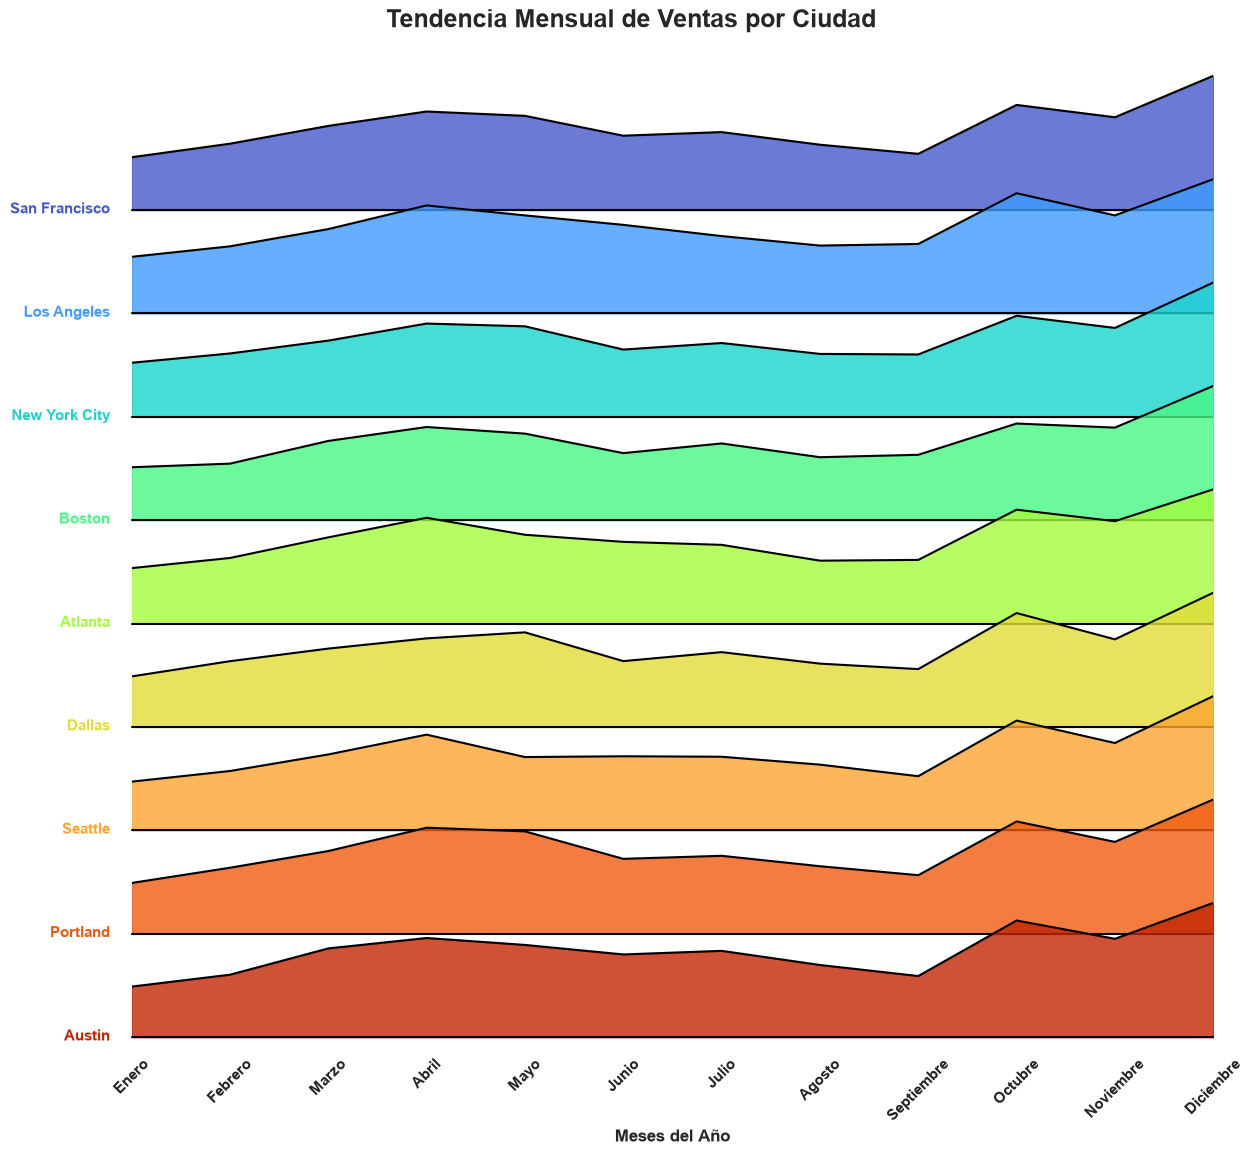

In [55]:
# Agrupamos las ventas totales por Ciudad y por Mes
df_tendencia = df.groupby(['Ciudad', 'Mes'])['Venta'].sum().reset_index()

# Ordenamos las ciudades por ventas totales 
orden_ciudades = df.groupby('Ciudad')['Venta'].sum().sort_values(ascending=False).index
df_tendencia['Ciudad'] = pd.Categorical(df_tendencia['Ciudad'], categories=orden_ciudades, ordered=True)
df_tendencia = df_tendencia.sort_values(['Ciudad', 'Mes'])

# prueba de paleta de colores
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
paleta = sns.color_palette("turbo", len(orden_ciudades))

# 3. Creamos el FacetGrid separando por 'Ciudad'

g = sns.FacetGrid(df_tendencia, row="Ciudad", hue="Ciudad", aspect=10, height=1.2, palette=paleta, sharey=False)

# funcion para color
def plot_area(x, y, color, **kwargs):
    ax = plt.gca()
    # línea principal
    ax.plot(x, y, color="black", lw=1.5)
    # área bajo la curva
    ax.fill_between(x, y, color=color, alpha=0.8)

# mapa para mes y venta
g.map(plot_area, "Mes", "Venta")
g.map(plt.axhline, y=0, lw=1.5, clip_on=False, color="black")
g.fig.subplots_adjust(hspace=-0.3)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# nombres de ciudades
for i, ax in enumerate(g.axes.flat):
    if i < len(orden_ciudades):
        ax.text(-0.02, 0.05, orden_ciudades[i], fontweight='bold', fontsize=11,
                color=paleta[i], ha="right", va="center", transform=ax.transAxes)


g.figure.suptitle('Tendencia Mensual de Ventas por Ciudad', fontsize=18, fontweight='bold', y=1.02)

plt.xticks(range(1, 13), meses_nombres, rotation=45, fontsize=11, fontweight='bold')
plt.xlabel('Meses del Año', fontsize=12, fontweight='bold')

g.set(xlim=(1, 12)) 

plt.show()

In [56]:
# comparación entre ventas y cantidad de habitantes
df_ventas_ciudad = ciudades_con_mas_ventas.reset_index()

df_comparacion = pd.merge(df_ventas_ciudad, df_habitantes, on='Ciudad')

# Ventas per cápita (Ventas por habitante)
df_comparacion['Ventas_per_capita ($)'] = df_comparacion['Venta'] / df_comparacion['Habitantes']

# Ordenamos de mayor a menor
df_comparacion = df_comparacion.sort_values(by='Ventas_per_capita ($)', ascending=False)

print(df_comparacion)

          Ciudad       Venta  Habitantes  Ventas_per_capita ($)
0  San Francisco  8262203.91      827526               9.984223
3         Boston  3661642.01      675000               5.424655
4        Atlanta  2795498.58      530000               5.274526
7       Portland  2320490.61      652500               3.556307
6        Seattle  2747755.48      781000               3.518253
5         Dallas  2767975.40     1300000               2.129212
8         Austin  1819581.75     1000000               1.819582
1    Los Angeles  5452570.80     3980000               1.369993
2  New York City  4664317.43     8260000               0.564687


### Opciones de Gráficos según densidad de población

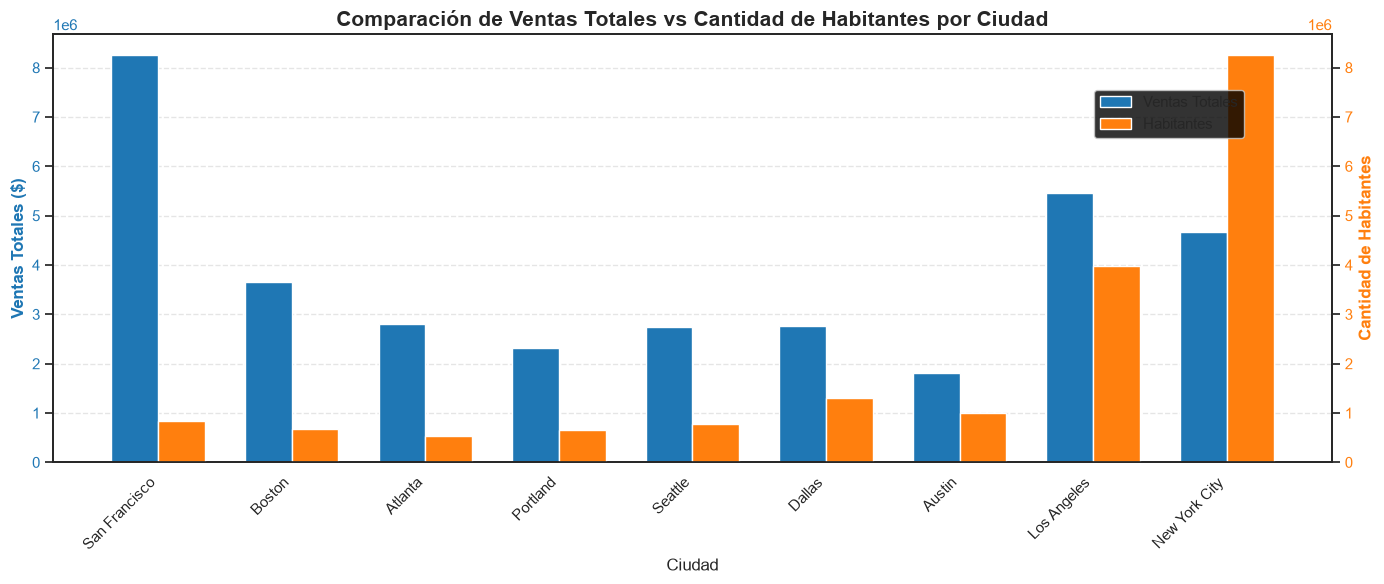

In [58]:


# Extraemos los datos del dataframe de comparación
ciudades = df_comparacion['Ciudad']
ventas = df_comparacion['Venta']
habitantes = df_comparacion['Habitantes']

# Configuramos las posiciones en el eje X y el ancho de las barras
x = np.arange(len(ciudades))
ancho = 0.35 

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje Y Izquierdo: Ventas
color_ventas = 'tab:blue'
ax1.set_xlabel('Ciudad', fontsize=12)
ax1.set_ylabel('Ventas Totales ($)', color=color_ventas, fontsize=12, fontweight='bold')
ax1.bar(x - ancho/2, ventas, ancho, label='Ventas Totales', color=color_ventas)
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.set_xticks(x)
ax1.set_xticklabels(ciudades, rotation=45, ha='right')

# Eje Y Derecho: Habitantes
ax2 = ax1.twinx() 
color_hab = 'tab:orange'
ax2.set_ylabel('Cantidad de Habitantes', color=color_hab, fontsize=12, fontweight='bold')
ax2.bar(x + ancho/2, habitantes, ancho, label='Habitantes', color=color_hab)
ax2.tick_params(axis='y', labelcolor=color_hab)

# Título, grilla y leyenda conjunta
plt.title('Comparación de Ventas Totales vs Cantidad de Habitantes por Ciudad', fontsize=15, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))

plt.tight_layout()
plt.show()

C:\Users\Brenda\AppData\Local\Temp\ipykernel_26188\535823713.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


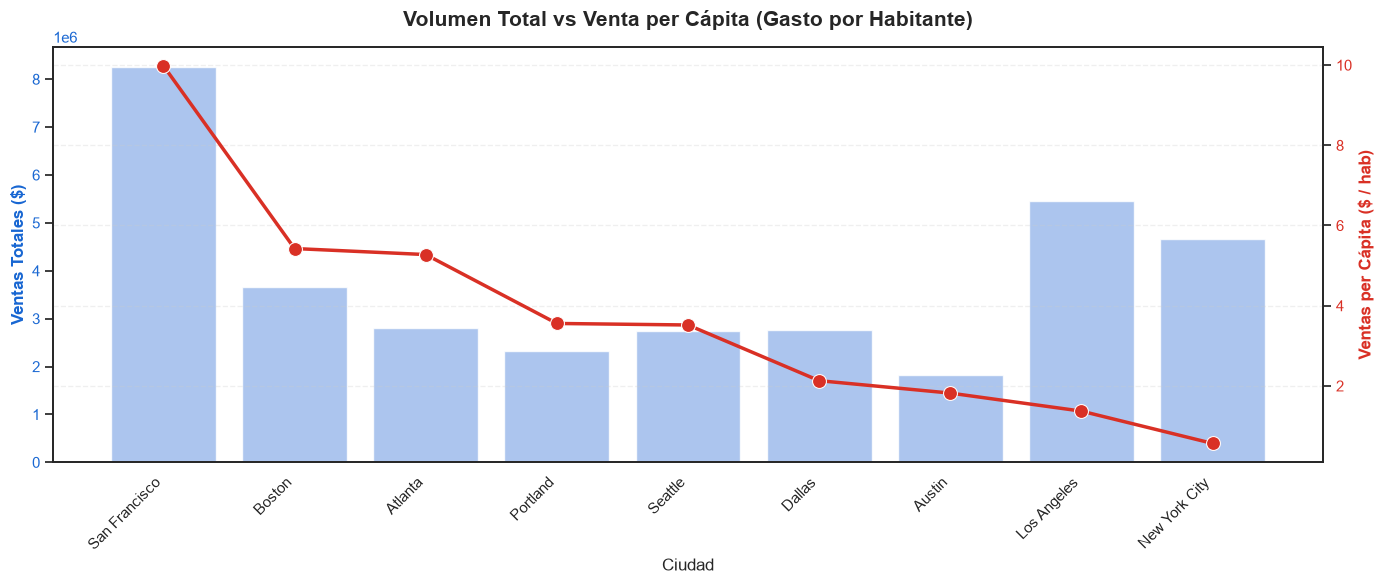

In [59]:

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje izquierdo: Barras para Ventas Totales
sns.barplot(data=df_comparacion, x='Ciudad', y='Venta', color='#8ab4f8', ax=ax1, alpha=0.8)
ax1.set_xlabel('Ciudad', fontsize=12)
ax1.set_ylabel('Ventas Totales ($)', color='#1967d2', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1967d2')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Eje derecho: Línea para Ventas Per Cápita
ax2 = ax1.twinx()
sns.lineplot(data=df_comparacion, x='Ciudad', y='Ventas_per_capita ($)', 
             color='#d93025', marker='o', markersize=10, linewidth=2.5, ax=ax2)
ax2.set_ylabel('Ventas per Cápita ($ / hab)', color='#d93025', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d93025')

plt.title('Volumen Total vs Venta per Cápita (Gasto por Habitante)', fontsize=15, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
# Gráfico de barras interactivo
fig = px.bar(
    df_comparacion, 
    x='Ciudad', 
    y='Ventas_per_capita ($)',
    color='Venta',
    text_auto='.2f', 
    title='Ventas per Cápita por Ciudad',
    labels={'Venta': 'Ventas Totales ($)'},
    color_continuous_scale='oxy' 
)
# https://plotly.com/python/builtin-colorscales/
#Paletas probadas bugn, Tealgrn, magenta, earth, phase, edge,  oxy 
# Mejoramos el diseño del texto y el fondo
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.update_layout(
    xaxis_title="Ciudad",
    yaxis_title="Ventas per Cápita ($ por habitante)",
    plot_bgcolor='white',
    hovermode="x"
)

fig.show()

### comparado con ingreso per capita

In [ ]:

#  lo mergeamos
if 'PerCapitaIncome_2023_USD' not in df_comparacion.columns:
    df_comparacion = pd.merge(
        df_comparacion,
        ingresos_per_capita,
        on='Ciudad',
        how='left'
    )

# Ordenamos por ventas para que el gráfico tenga coherencia visual
df_comparacion = df_comparacion.sort_values('Venta', ascending=False).reset_index(drop=True)

print(df_comparacion[['Ciudad', 'Venta', 'Habitantes', 'PerCapitaIncome_2023_USD']])

          Ciudad       Venta  Habitantes  PerCapitaIncome_2023_USD
0  San Francisco  8262203.91      827526                    130730
1    Los Angeles  5452570.80     3980000                     80898
2  New York City  4664317.43     8260000                    214991
3         Boston  3661642.01      675000                     94082
4        Atlanta  2795498.58      530000                     65382
5         Dallas  2767975.40     1300000                     74165
6        Seattle  2747755.48      781000                     99339
7       Portland  2320490.61      652500                     69435
8         Austin  1819581.75     1000000                     75119


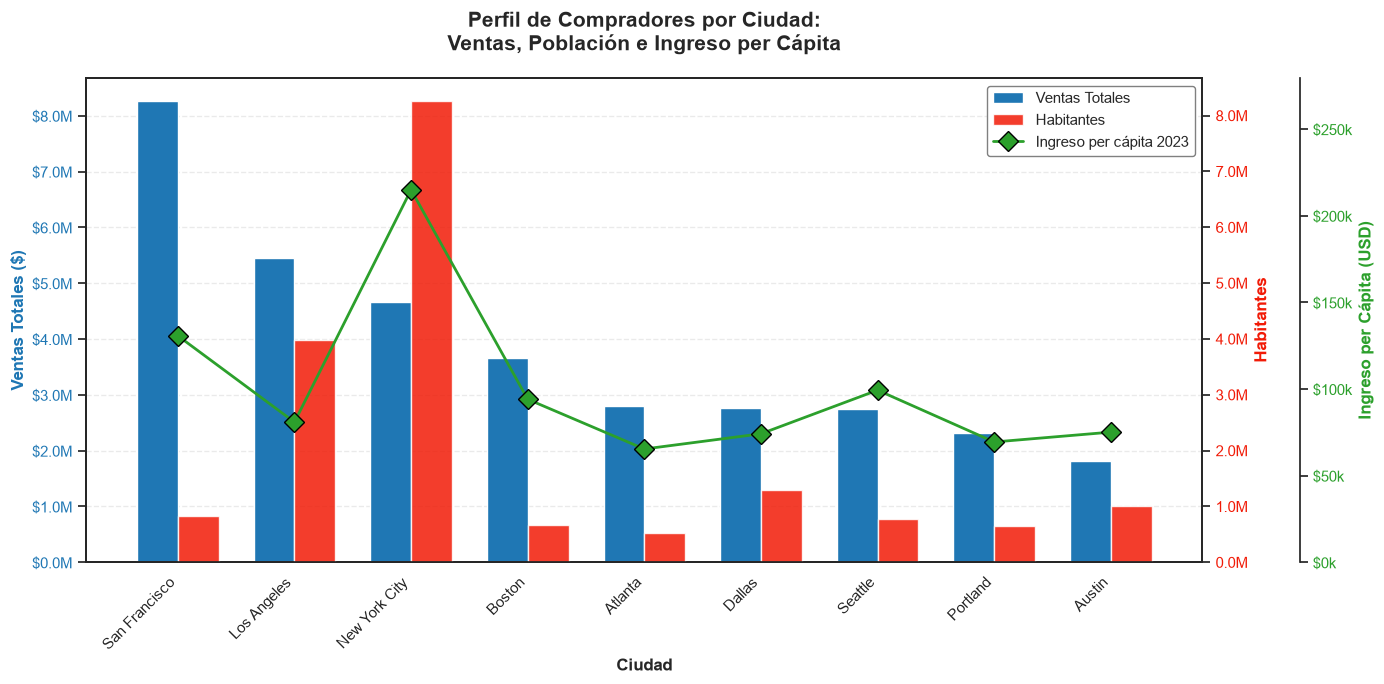

In [144]:
# Datos
ciudades = df_comparacion['Ciudad']
ventas = df_comparacion['Venta']
habitantes = df_comparacion['Habitantes']
ingreso_pc = df_comparacion['PerCapitaIncome_2023_USD']

x = np.arange(len(ciudades))
ancho = 0.35

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Eje izquierdo: Ventas (barras) ---
color_ventas = '#1f77b4'
barras_ventas = ax1.bar(
    x - ancho/2, ventas, ancho,
    label='Ventas Totales', color=color_ventas, zorder=3
)
ax1.set_ylabel('Ventas Totales ($)', color=color_ventas, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'${v/1e6:.1f}M'))

# --- Eje derecho: Habitantes (barras) e Ingreso per cápita (línea + puntos) ---
ax2 = ax1.twinx()

color_hab = "#f11b07"
barras_hab = ax2.bar(
    x + ancho/2, habitantes, ancho,
    label='Habitantes', color=color_hab, zorder=3, alpha=0.85
)
ax2.set_ylabel('Habitantes', color=color_hab, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_hab)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))

# --- Tercer eje (compartido): Ingreso per cápita como línea de puntos ---
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 70))  # Lo desplazamos hacia afuera
color_ing = '#2ca02c'
linea_ing, = ax3.plot(
    x, ingreso_pc,
    color=color_ing, marker='D', markersize=10,
    linestyle='-', linewidth=2, zorder=5,
    label='Ingreso per cápita 2023',
    markeredgecolor='black', markeredgewidth=1
)
ax3.set_ylabel('Ingreso per Cápita (USD)', color=color_ing, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_ing)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'${v/1e3:.0f}k'))
ax3.set_ylim(0, ingreso_pc.max() * 1.3)

# --- Eje X ---
ax1.set_xticks(x)
ax1.set_xticklabels(ciudades, rotation=45, ha='right', fontsize=11)
ax1.set_xlabel('Ciudad', fontsize=12, fontweight='bold')

# --- Título y leyenda ---
plt.title(
    'Perfil de Compradores por Ciudad:\nVentas, Población e Ingreso per Cápita',
    fontsize=15, fontweight='bold', pad=20
)

# Leyenda combinada de los tres ejes
lineas = [barras_ventas, barras_hab, linea_ing]
etiquetas = [l.get_label() for l in lineas]
# ver mejorar colores
ax1.legend(
    lineas, etiquetas,
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='gray',
    framealpha=1.0
)

ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

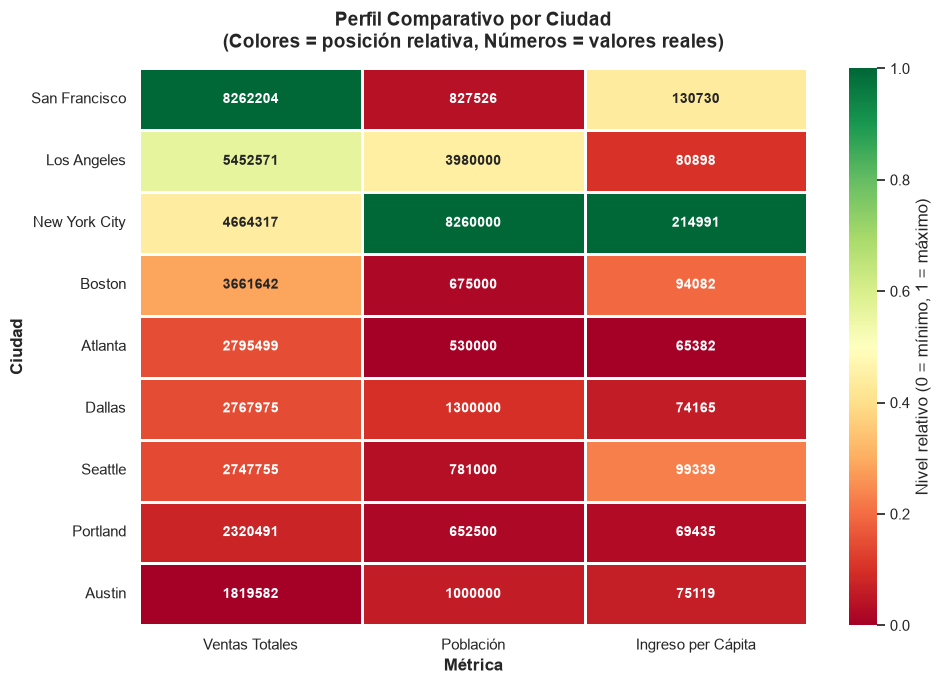

In [131]:
# Construimos un DataFrame con las 3 métricas normalizadas (0 a 1)
perfil = df_comparacion.set_index('Ciudad')[['Venta', 'Habitantes', 'PerCapitaIncome_2023_USD']].copy()
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

# Renombramos para el gráfico
perfil_norm.columns = ['Ventas Totales', 'Población', 'Ingreso per Cápita']

# Ordenamos por ventas
perfil_norm = perfil_norm.sort_values('Ventas Totales', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    perfil_norm,
    annot=perfil.values,  # Mostramos valores reales
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Nivel relativo (0 = mínimo, 1 = máximo)'},
    annot_kws={'size': 10, 'weight': 'bold'},
    ax=ax
)

ax.set_title(
    'Perfil Comparativo por Ciudad\n(Colores = posición relativa, Números = valores reales)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Métrica', fontsize=12, fontweight='bold')
ax.set_ylabel('Ciudad', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

### Ventas por Ciudad por mes

In [61]:


# Extraer la Ciudad separando la cadena de texto por las comas
ventas_ciudad_mes = df.groupby(['Mes', 'Ciudad'])['Venta'].sum().reset_index()
print(ventas_ciudad_mes)


     Mes         Ciudad       Venta
0      1        Atlanta   149159.54
1      1         Austin    88087.06
2      1         Boston   201088.49
3      1         Dallas   143462.51
4      1    Los Angeles   288601.90
..   ...            ...         ...
103   12    Los Angeles   684044.84
104   12  New York City   646770.83
105   12       Portland   303714.11
106   12  San Francisco  1106601.27
107   12        Seattle   387317.93

[108 rows x 3 columns]


In [62]:
# 1.Elegir el mes
mes_elegido = 12


ventas_del_mes = ventas_ciudad_mes[ventas_ciudad_mes['Mes'] == mes_elegido]

# 3. Ordena los resultados de mayor a menor para facilitar el análisis
ventas_del_mes = ventas_del_mes.sort_values('Venta', ascending=False)

# 4. Imprime el resultado mostrando solo Ciudad y Venta (el mes ya lo sabemos)
print(f"--- Ventas por ciudad en el mes {mes_elegido} ---")
print(ventas_del_mes[['Ciudad', 'Venta']])

--- Ventas por ciudad en el mes 12 ---
            Ciudad       Venta
106  San Francisco  1106601.27
103    Los Angeles   684044.84
104  New York City   646770.83
101         Boston   509599.16
107        Seattle   387317.93
102         Dallas   380718.85
99         Atlanta   360899.26
105       Portland   303714.11
100         Austin   233777.09


C:\Users\Brenda\AppData\Local\Temp\ipykernel_26188\3796324435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_del_mes, x='Ciudad', y='Venta', palette='viridis')


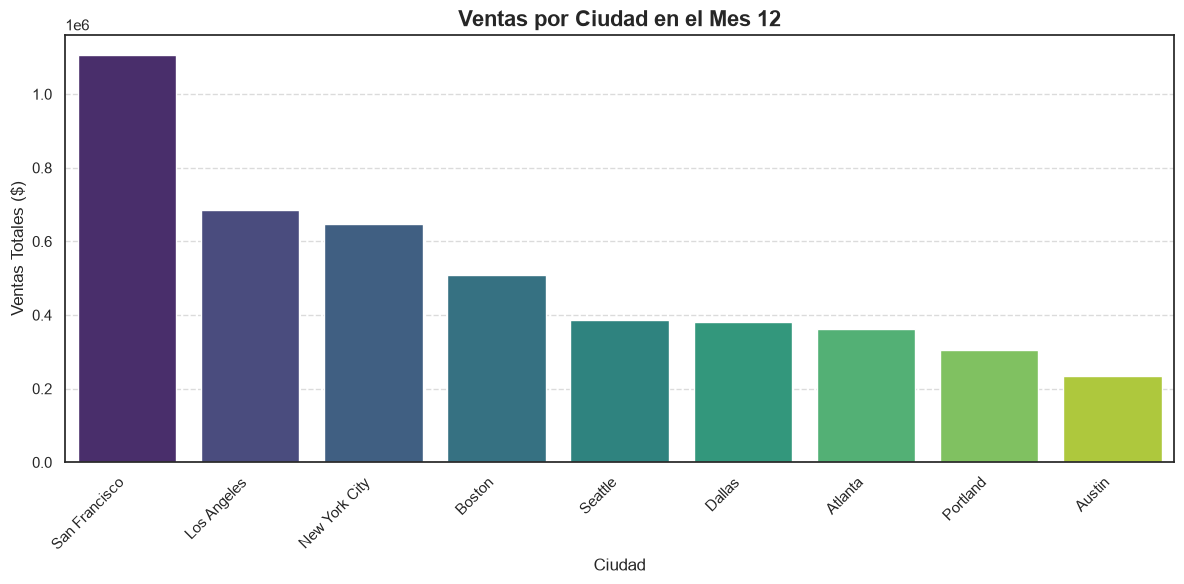

In [63]:
plt.figure(figsize=(12, 6))
# Creamos el gráfico de barras usando el dataframe ya filtrado y ordenado
sns.barplot(data=ventas_del_mes, x='Ciudad', y='Venta', palette='viridis')

# Personalizamos los títulos y etiquetas
plt.title(f'Ventas por Ciudad en el Mes {mes_elegido}', fontsize=16, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)

# Rotamos los nombres de las ciudades 45 grados para que no se superpongan
plt.xticks(rotation=45, ha='right') 

# Agregamos una grilla horizontal sutil para facilitar la lectura de los valores
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustamos automáticamente los márgenes para que no se corte ningún texto
plt.tight_layout()

# Mostramos el gráfico
plt.show()

### Ingreso por hora

In [64]:
# Ingresos por Hora
pedidos_por_hora = df.groupby('Hora')['ID de Pedido'].count()
print(pedidos_por_hora)

# Ingresos Totales por Hora
ingresos_por_hora = df.groupby('Hora')['Venta'].sum()
print(ingresos_por_hora)

# Productos por hora
productos_por_hora = df.groupby('Hora')['Cantidad Pedida'].sum()
print(productos_por_hora)

Hora
0      3910
1      2350
2      1243
3       831
4       854
5      1321
6      2482
7      4011
8      6256
9      8748
10    10944
11    12411
12    12587
13    12129
14    10984
15    10175
16    10384
17    10899
18    12280
19    12905
20    12228
21    10921
22     8822
23     6275
Name: ID de Pedido, dtype: int64
Hora
0      713721.27
1      460866.88
2      234851.44
3      145757.89
4      162661.01
5      230679.82
6      448113.00
7      744854.12
8     1192348.97
9     1639030.58
10    1944286.77
11    2300610.24
12    2316821.34
13    2155389.80
14    2083672.73
15    1941549.60
16    1904601.31
17    2129361.61
18    2219348.30
19    2412938.54
20    2281716.24
21    2042000.86
22    1607549.21
23    1179304.44
Name: Venta, dtype: float64
Hora
0      4428
1      2619
2      1398
3       928
4       937
5      1493
6      2810
7      4556
8      7002
9      9816
10    12308
11    14005
12    14202
13    13685
14    12362
15    11391
16    11662
17    12229
18    13802


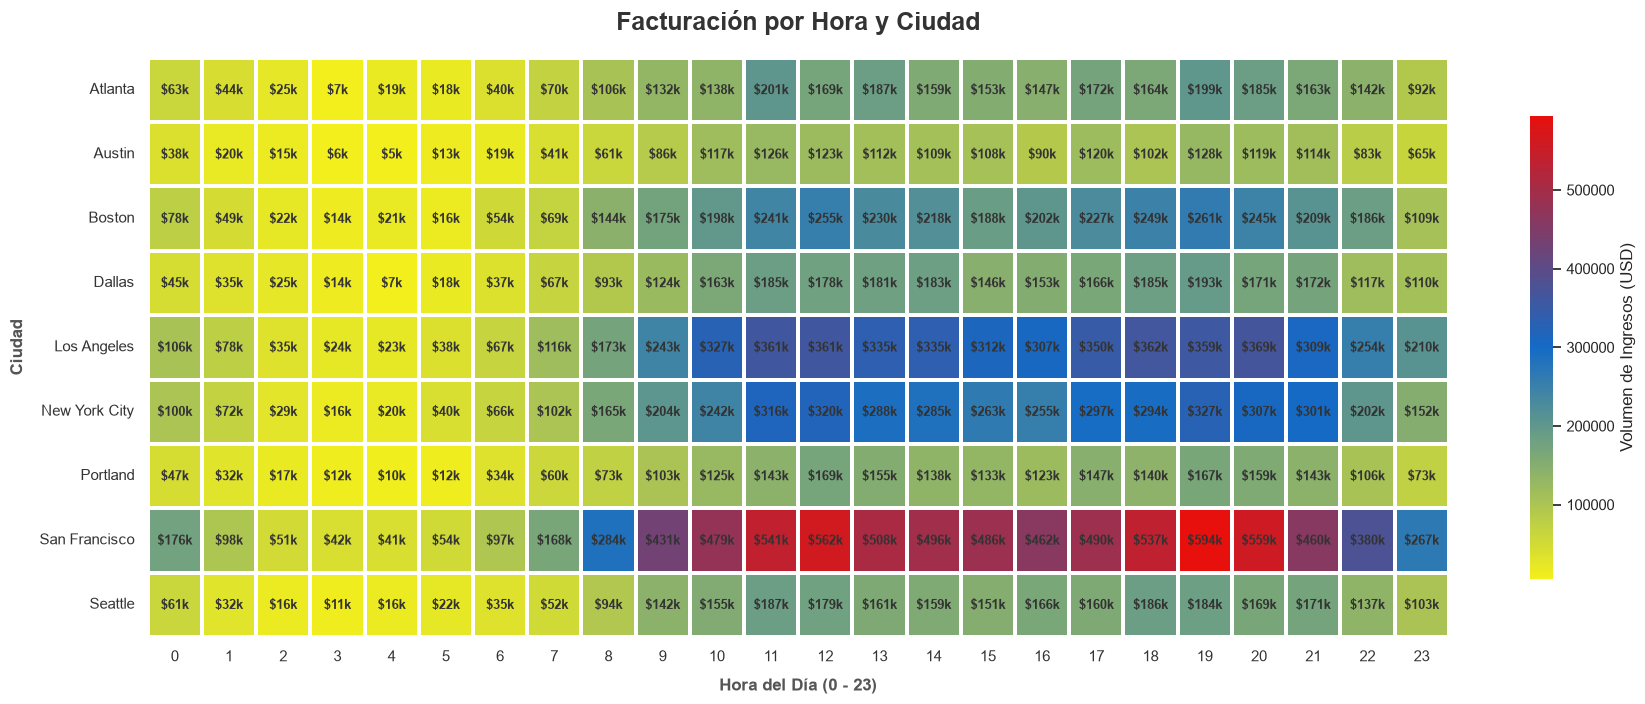

In [65]:


matriz_ingresos = df.groupby(['Ciudad', 'Hora'])['Venta'].sum().unstack(fill_value=0)

anotaciones = matriz_ingresos.apply(lambda col: col.map(lambda v: f"${v/1000:.0f}k" if v > 0 else ""))

alto_figura = max(6, len(matriz_ingresos) * 0.8)
fig, ax = plt.subplots(figsize=(18, alto_figura), facecolor='#FFFFFF')

# Paleta de colores de interfaz 
# Blanco roto (sin ventas) -> Azul sólido (#1E7EE4) -> Naranja de acento (#F1934E, horas de mayor facturación)
colores = ["#F3EF1C", "#146AC6", "#E7100D"]
mapa_colores = LinearSegmentedColormap.from_list('ingresos_ciudades', colores)

#  mapa de calor
sns.heatmap(matriz_ingresos, 
            cmap=mapa_colores, 
            annot=anotaciones,     
            fmt="",               
            linewidths=1.5,        
            linecolor='#FFFFFF',
            cbar_kws={'label': 'Volumen de Ingresos (USD)', 'shrink': 0.8},
            annot_kws={"size": 9, "weight": "bold", "color": "#333333"},
            ax=ax)

# Jerarquía tipográfica y limpieza de ejes
ax.set_title('Facturación por Hora y Ciudad', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Hora del Día (0 - 23)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Ciudad', fontsize=12, fontweight='bold', labelpad=10, color='#555555')

ax.tick_params(axis='x', colors='#333333', labelsize=11)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

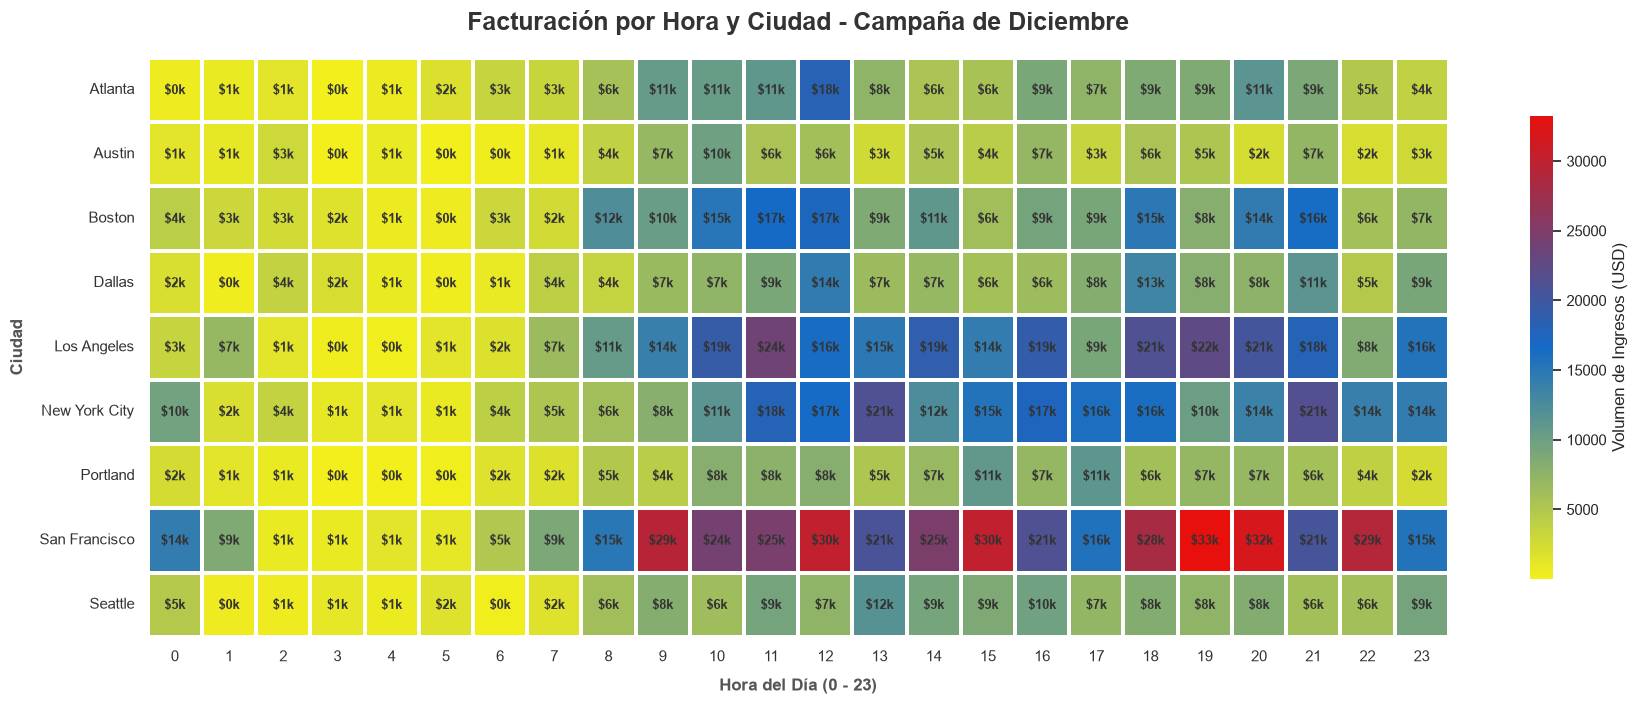

In [66]:
# mes enero


df_diciembre = df[df['Mes'] == 1]

# 2. Agrupar por Ciudad y Hora usando únicamente el DataFrame de diciembre
matriz_ingresos_dic = df_diciembre.groupby(['Ciudad', 'Hora'])['Venta'].sum().unstack(fill_value=0)

# 3. Formatear las anotaciones a miles (k) para mantener las celdas despejadas
anotaciones = matriz_ingresos_dic.apply(lambda col: col.map(lambda v: f"${v/1000:.0f}k" if v > 0 else ""))

# 4. Configuración dinámica del lienzo
alto_figura = max(6, len(matriz_ingresos_dic) * 0.8)
fig, ax = plt.subplots(figsize=(18, alto_figura), facecolor='#FFFFFF')

# 5. Paleta de colores 
# Amarillo para inactividad, azul  (#1E7EE4) para volumen regular, 
# y naranja de acento (#E7100D) para los picos máximos de diciembre.
colores = ["#F3EF1C", "#146AC6", "#E7100D"]
mapa_colores = LinearSegmentedColormap.from_list('ingresos_diciembre', colores)

# 6. Renderizado del mapa de calor
sns.heatmap(matriz_ingresos_dic, 
            cmap=mapa_colores, 
            annot=anotaciones,     
            fmt="",                
            linewidths=1.5,        
            linecolor='#FFFFFF',
            cbar_kws={'label': 'Volumen de Ingresos (USD)', 'shrink': 0.8},
            annot_kws={"size": 9, "weight": "bold", "color": "#333333"},
            ax=ax)

# 7. Ajustes de jerarquía tipográfica para el nuevo contexto
ax.set_title('Facturación por Hora y Ciudad - Campaña de Diciembre', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Hora del Día (0 - 23)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Ciudad', fontsize=12, fontweight='bold', labelpad=10, color='#555555')

# Limpieza de los ejes
ax.tick_params(axis='x', colors='#333333', labelsize=11)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

## Patrones de compras


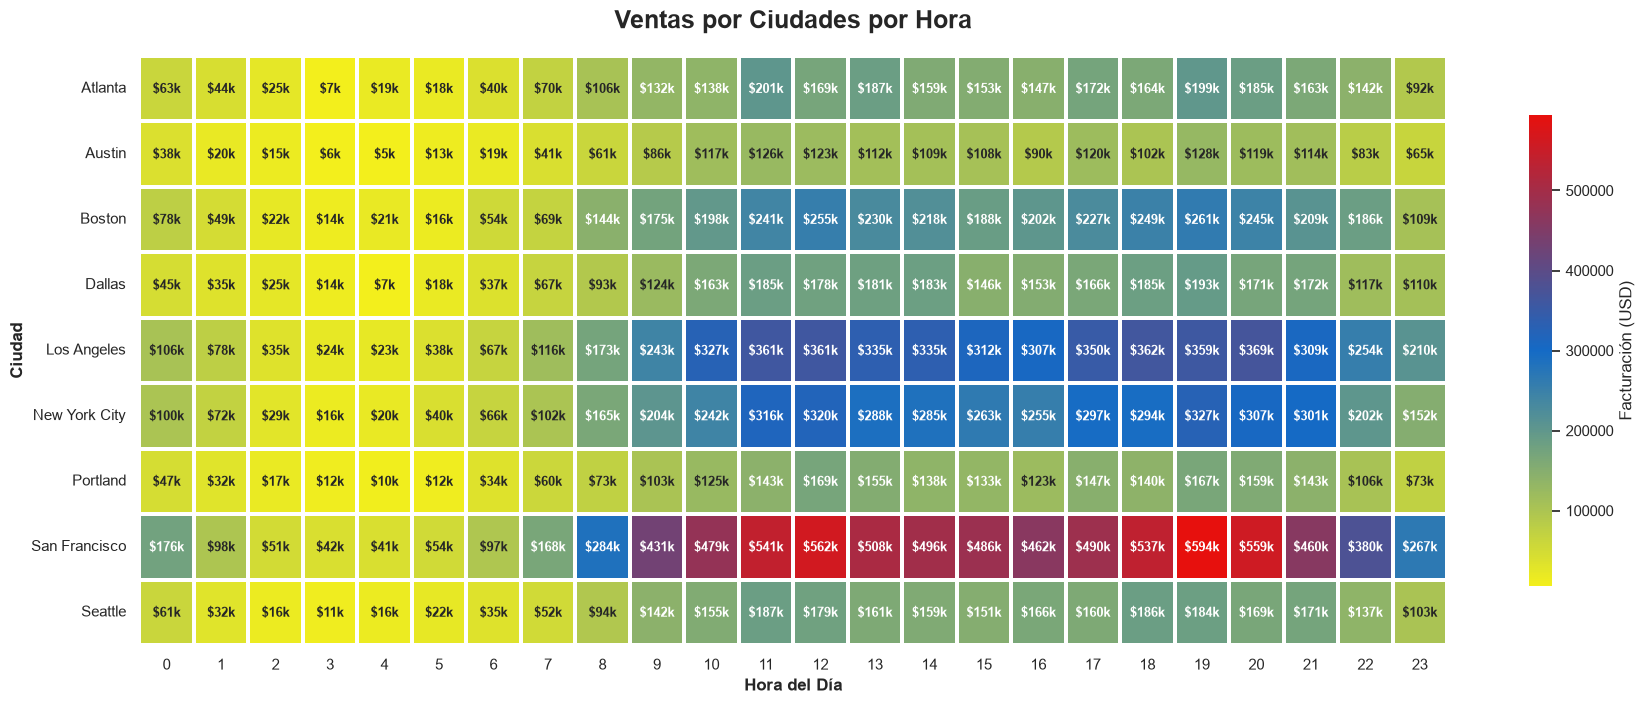

In [67]:

# Agrupar facturación por Ciudad y Hora
matriz_ciudades = df.groupby(['Ciudad', 'Hora'])['Venta'].sum().unstack(fill_value=0)

anotaciones_ciudades = matriz_ciudades.map(lambda v: f"${v/1000:.0f}k" if v > 0 else "")

# Configuración 
alto_figura = max(6, len(matriz_ciudades) * 0.8)
fig, ax = plt.subplots(figsize=(18, alto_figura), facecolor='#FFFFFF')

colores = ["#F3EF1C", "#146AC6", "#E7100D"]
mapa_colores = LinearSegmentedColormap.from_list('ingresos_ciudades', colores)

sns.heatmap(matriz_ciudades, 
            cmap=mapa_colores, 
            annot=anotaciones_ciudades, 
            fmt="", 
            linewidths=1.5, 
            linecolor='#FFFFFF',
            cbar_kws={'label': 'Facturación (USD)', 'shrink': 0.8},
            # Solución 2: Eliminación del color forzado en el texto
            annot_kws={"size": 9, "weight": "bold"},
            ax=ax)

ax.set_title('Ventas por Ciudades por Hora', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Hora del Día', fontsize=12, fontweight='bold')
ax.set_ylabel('Ciudad', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

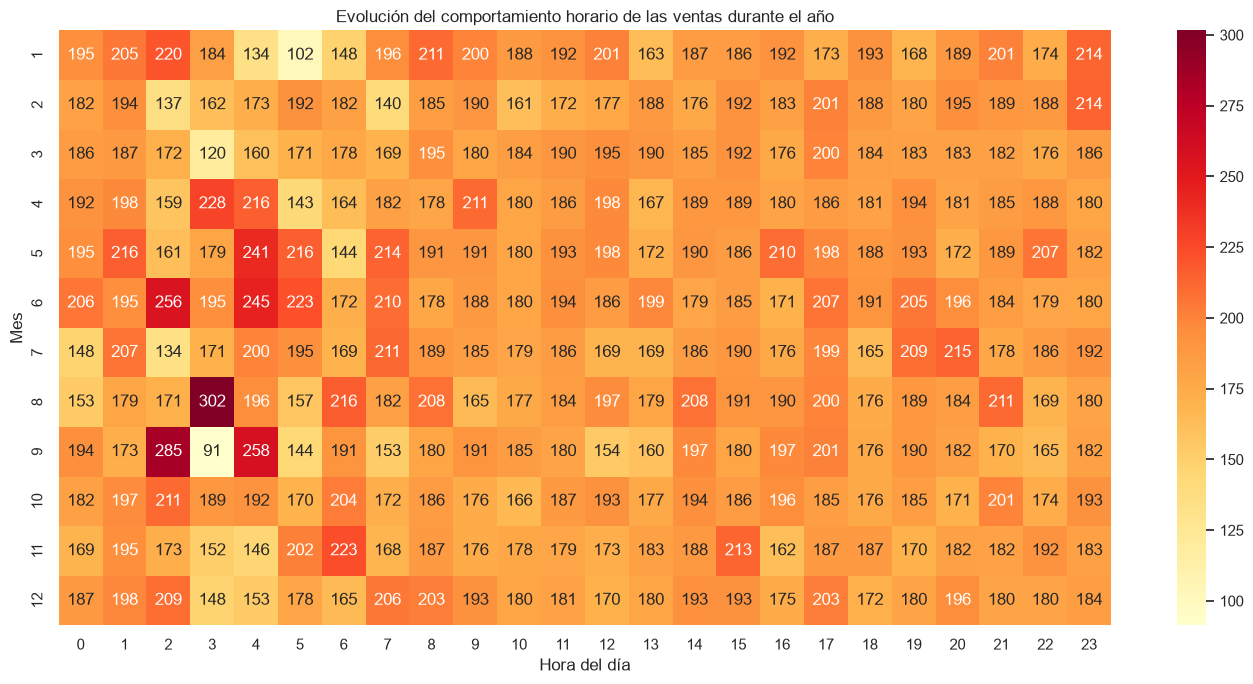

In [68]:


heatmap_data = df.pivot_table(
    index="Mes",
    columns="Hora",
    values="Venta",
    aggfunc="mean"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.xlabel("Hora del día")
plt.ylabel("Mes")
plt.title("Evolución del comportamiento horario de las ventas durante el año")

plt.tight_layout()
plt.show()

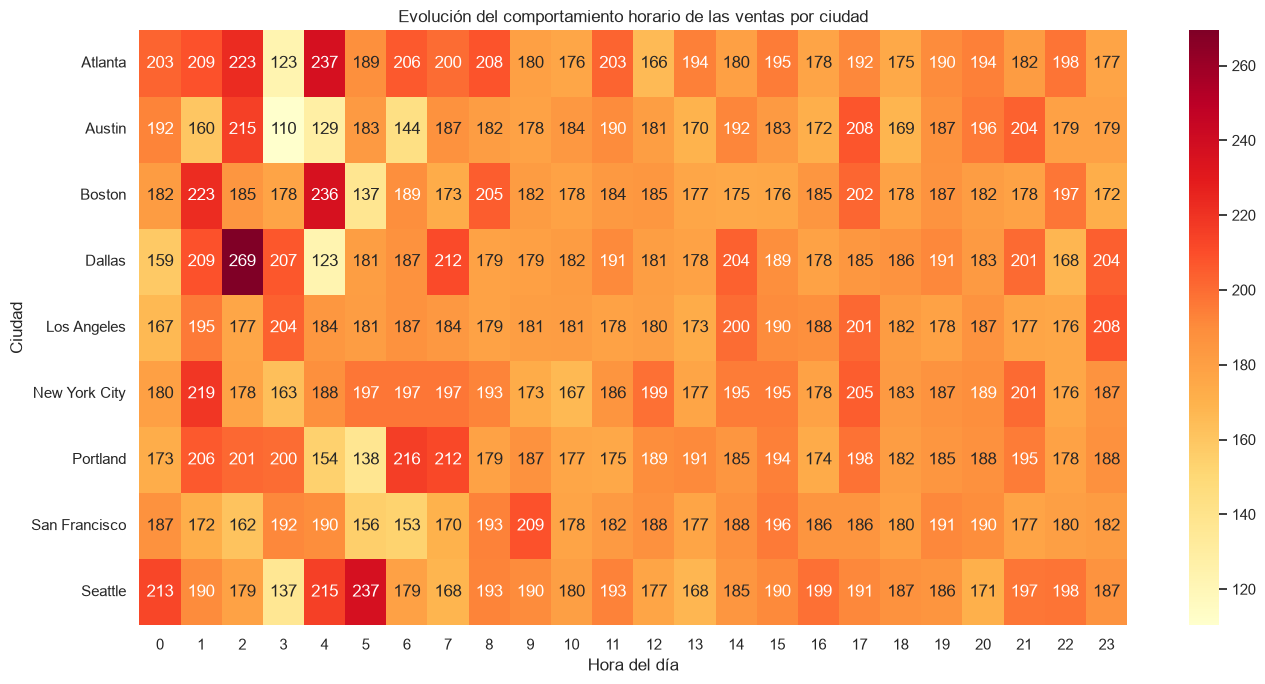

In [69]:

heatmap_data = df.pivot_table(
    index="Ciudad",  
    columns="Hora",
    values="Venta",
    aggfunc="mean"   
)


plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.xlabel("Hora del día")
plt.ylabel("Ciudad")
plt.title("Evolución del comportamiento horario de las ventas por ciudad")

plt.tight_layout()
plt.show()

TEST DE NORMALIDAD: HORA DE COMPRA
Muestra analizada: 185,950 registros
Media: 14.41
Mediana: 15.00
Desviación estándar: 5.42
Asimetría (skewness): -0.530
Curtosis: -0.129

SHAPIRO-WILK
------------------------------------------------------------
Estadístico W = 0.9604
p-valor       = 6.7181e-35
Conclusión: se rechaza la hipótesis de normalidad.

KOLMOGOROV-SMIRNOV
------------------------------------------------------------
Estadístico D = 0.0869
p-valor       = 0.0000e+00
Conclusión: se rechaza la hipótesis de normalidad.



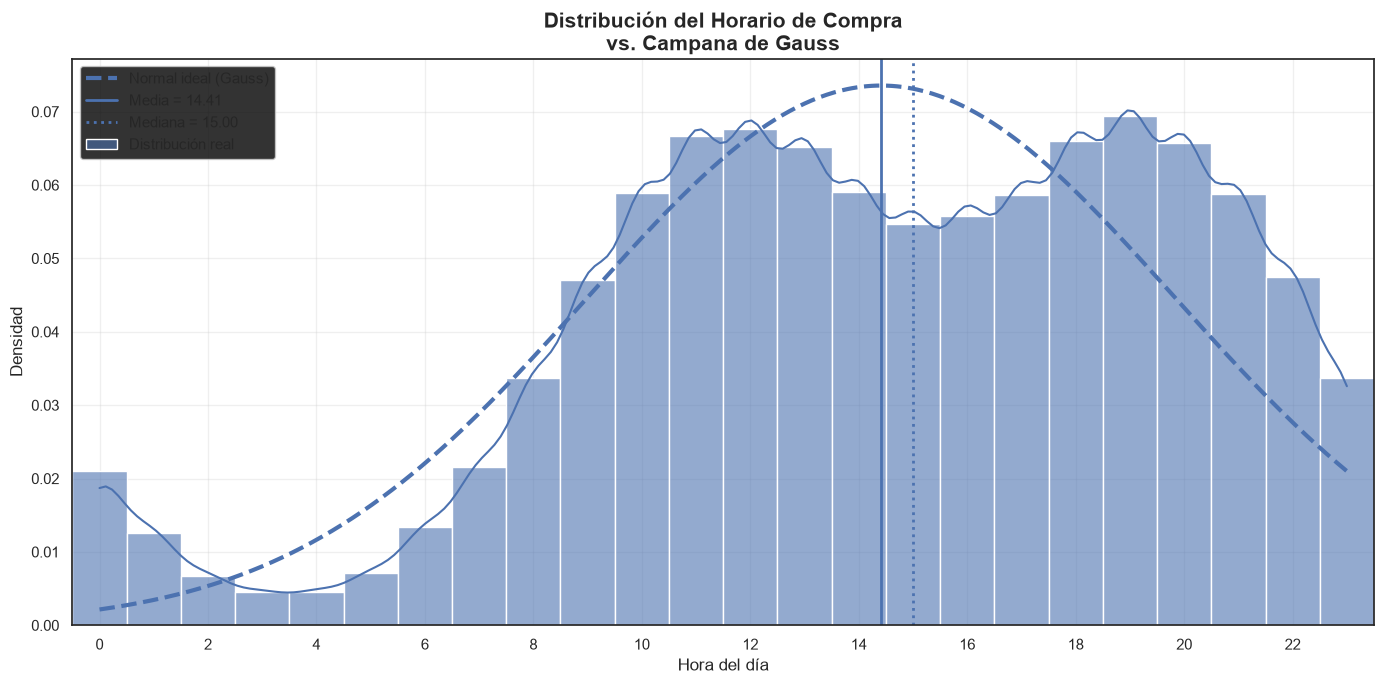

In [ ]:

hora = pd.to_numeric(df['Hora'], errors='coerce').dropna().astype(float)

print("=" * 60)
print("TEST DE NORMALIDAD: HORA DE COMPRA")
print("=" * 60)

print(f"Muestra analizada: {len(hora):,} registros")
print(f"Media: {hora.mean():.2f}")
print(f"Mediana: {hora.median():.2f}")
print(f"Desviación estándar: {hora.std():.2f}")
print(f"Asimetría (skewness): {hora.skew():.3f}")
print(f"Curtosis: {hora.kurtosis():.3f}")
print()


# ============================================================
# TEST DE SHAPIRO-WILK
# ============================================================

# Shapiro-Wilk trabaja mejor con una submuestra
# cuando tenemos una cantidad de datos muy grande.

muestra_hora = hora.sample(
    n=min(5000, len(hora)),
    random_state=42
)

shapiro_hora = stats.shapiro(muestra_hora)

print("SHAPIRO-WILK")
print("-" * 60)
print(f"Estadístico W = {shapiro_hora.statistic:.4f}")
print(f"p-valor       = {shapiro_hora.pvalue:.4e}")

if shapiro_hora.pvalue > 0.05:
    print("Conclusión: no se rechaza la hipótesis de normalidad.")
else:
    print("Conclusión: se rechaza la hipótesis de normalidad.")

print()


# ============================================================
# TEST DE KOLMOGOROV-SMIRNOV
# ============================================================

# Convertimos explícitamente los datos a NumPy
# para evitar problemas de tipos con SciPy.

hora_np = hora.to_numpy(dtype=float)

# Estandarización:
# Z = (X - media) / desviación estándar

hora_z = (
    hora_np - hora_np.mean()
) / hora_np.std(ddof=1)

# Comparamos contra una distribución normal estándar N(0,1)

ks_hora = stats.kstest(
    hora_z,
    'norm'
)

print("KOLMOGOROV-SMIRNOV")
print("-" * 60)
print(f"Estadístico D = {ks_hora.statistic:.4f}")
print(f"p-valor       = {ks_hora.pvalue:.4e}")

if ks_hora.pvalue > 0.05:
    print("Conclusión: no se rechaza la hipótesis de normalidad.")
else:
    print("Conclusión: se rechaza la hipótesis de normalidad.")

print()



# GRÁFICO: DISTRIBUCIÓN REAL VS CAMPANA DE GAUSS


fig, ax = plt.subplots(figsize=(14, 7))



sns.histplot(
    hora,
    bins=np.arange(-0.5, 24.5, 1),
    kde=True,
    stat='density',
    alpha=0.60,
    ax=ax,
    label='Distribución real'
)


# ------------------------------------------------------------
# CAMPANA NORMAL TEÓRICA
# ------------------------------------------------------------

media = hora.mean()
desvio = hora.std()

x = np.linspace(
    0,
    23,
    500
)

y = stats.norm.pdf(
    x,
    loc=media,
    scale=desvio
)

ax.plot(
    x,
    y,
    linestyle='--',
    linewidth=3,
    label='Normal ideal (Gauss)'
)


# ------------------------------------------------------------
# LÍNEA DE LA MEDIA
# ------------------------------------------------------------

ax.axvline(
    media,
    linestyle='-',
    linewidth=2,
    label=f'Media = {media:.2f}'
)


# ------------------------------------------------------------
# LÍNEA DE LA MEDIANA
# ------------------------------------------------------------

mediana = hora.median()

ax.axvline(
    mediana,
    linestyle=':',
    linewidth=2,
    label=f'Mediana = {mediana:.2f}'
)


# ------------------------------------------------------------
# CONFIGURACIÓN DEL GRÁFICO
# ------------------------------------------------------------

ax.set_title(
    'Distribución del Horario de Compra\nvs. Campana de Gauss',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel(
    'Hora del día',
    fontsize=12
)

ax.set_ylabel(
    'Densidad',
    fontsize=12
)

ax.set_xlim(
    -0.5,
    23.5
)

ax.set_xticks(
    range(0, 24, 2)
)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

#### grafico de crestas

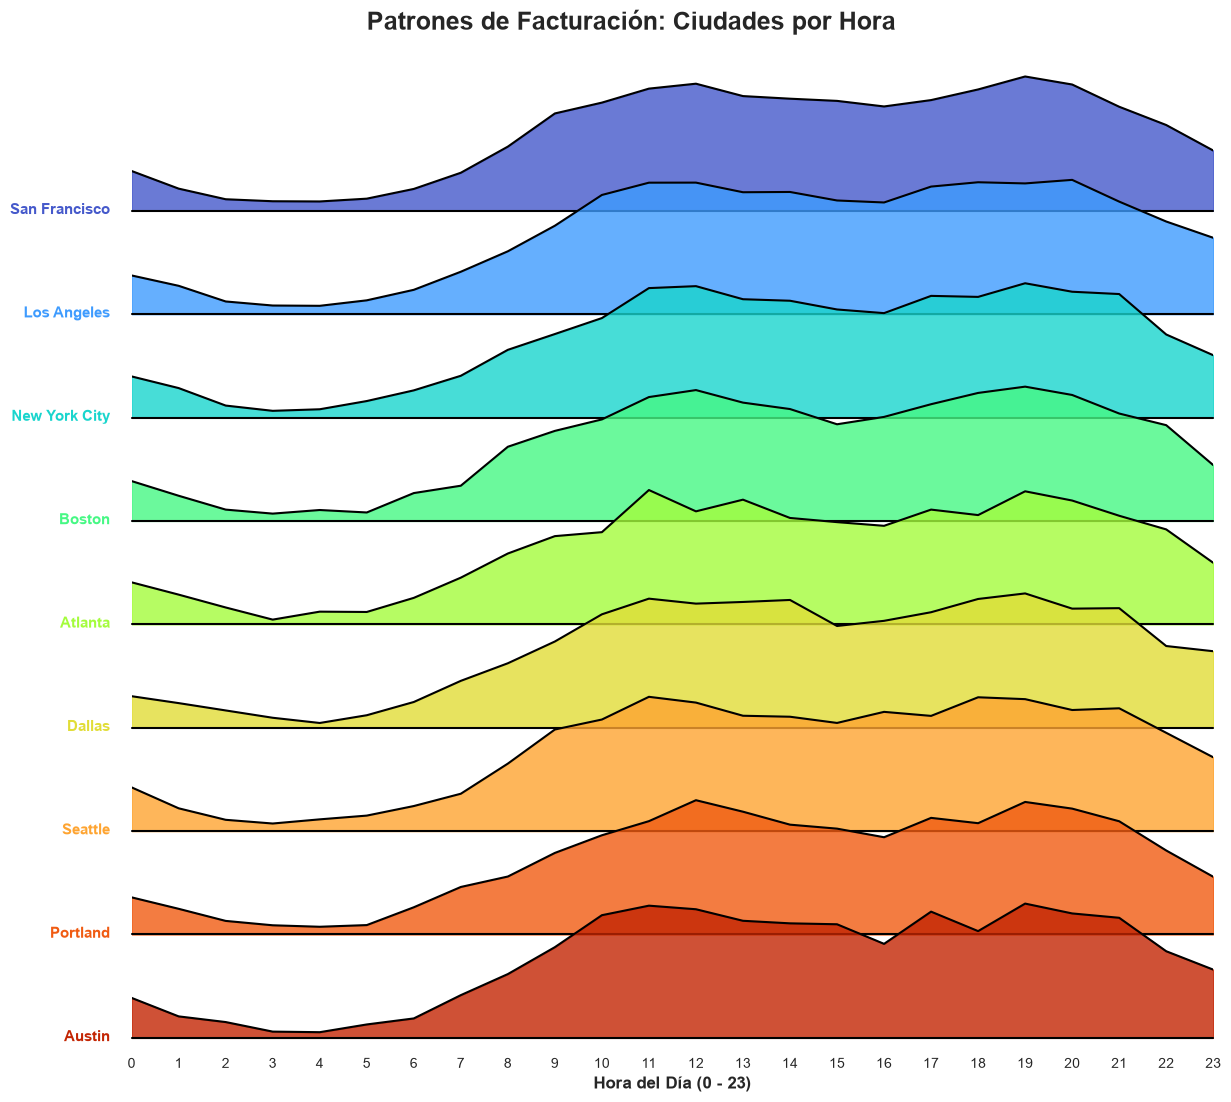

In [162]:



df_tendencia_hora = df.groupby(['Ciudad', 'Hora'])['Venta'].sum().reset_index()

# Ordenar las ciudades por volumen total de ventas para mantener jerarquía visual
orden_ciudades = df.groupby('Ciudad')['Venta'].sum().sort_values(ascending=False).index
df_tendencia_hora['Ciudad'] = pd.Categorical(df_tendencia_hora['Ciudad'], categories=orden_ciudades, ordered=True)
df_tendencia_hora = df_tendencia_hora.sort_values(['Ciudad', 'Hora'])

# Configurar el fondo transparente y la paleta de colores
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
paleta = sns.color_palette("turbo", len(orden_ciudades))

#. Crear el FacetGrid separando por 'Ciudad'

g = sns.FacetGrid(df_tendencia_hora, row="Ciudad", hue="Ciudad", aspect=10, height=1.2, palette=paleta, sharey=False)


def plot_area(x, y, color, **kwargs):
    ax = plt.gca()
    ax.plot(x, y, color="black", lw=1.5)
    ax.fill_between(x, y, color=color, alpha=0.8)

# función para datos de Hora y Venta
g.map(plot_area, "Hora", "Venta")
g.map(plt.axhline, y=0, lw=1.5, clip_on=False, color="black")

g.figure.subplots_adjust(hspace=-0.3)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Escribir el nombre de cada ciudad alineado a la izquierda
for i, ax in enumerate(g.axes.flat):
    if i < len(orden_ciudades):
        ax.text(-0.02, 0.05, orden_ciudades[i], fontweight='bold', fontsize=11,
                color=paleta[i], ha="right", va="center", transform=ax.transAxes)

g.figure.suptitle('Patrones de Facturación: Ciudades por Hora', fontsize=18, fontweight='bold', y=1.02)
plt.xlabel('Hora del Día (0 - 23)', fontsize=12, fontweight='bold')


plt.xticks(range(0, 24), fontsize=10)
g.set(xlim=(0, 23))

plt.show()

### Por producto

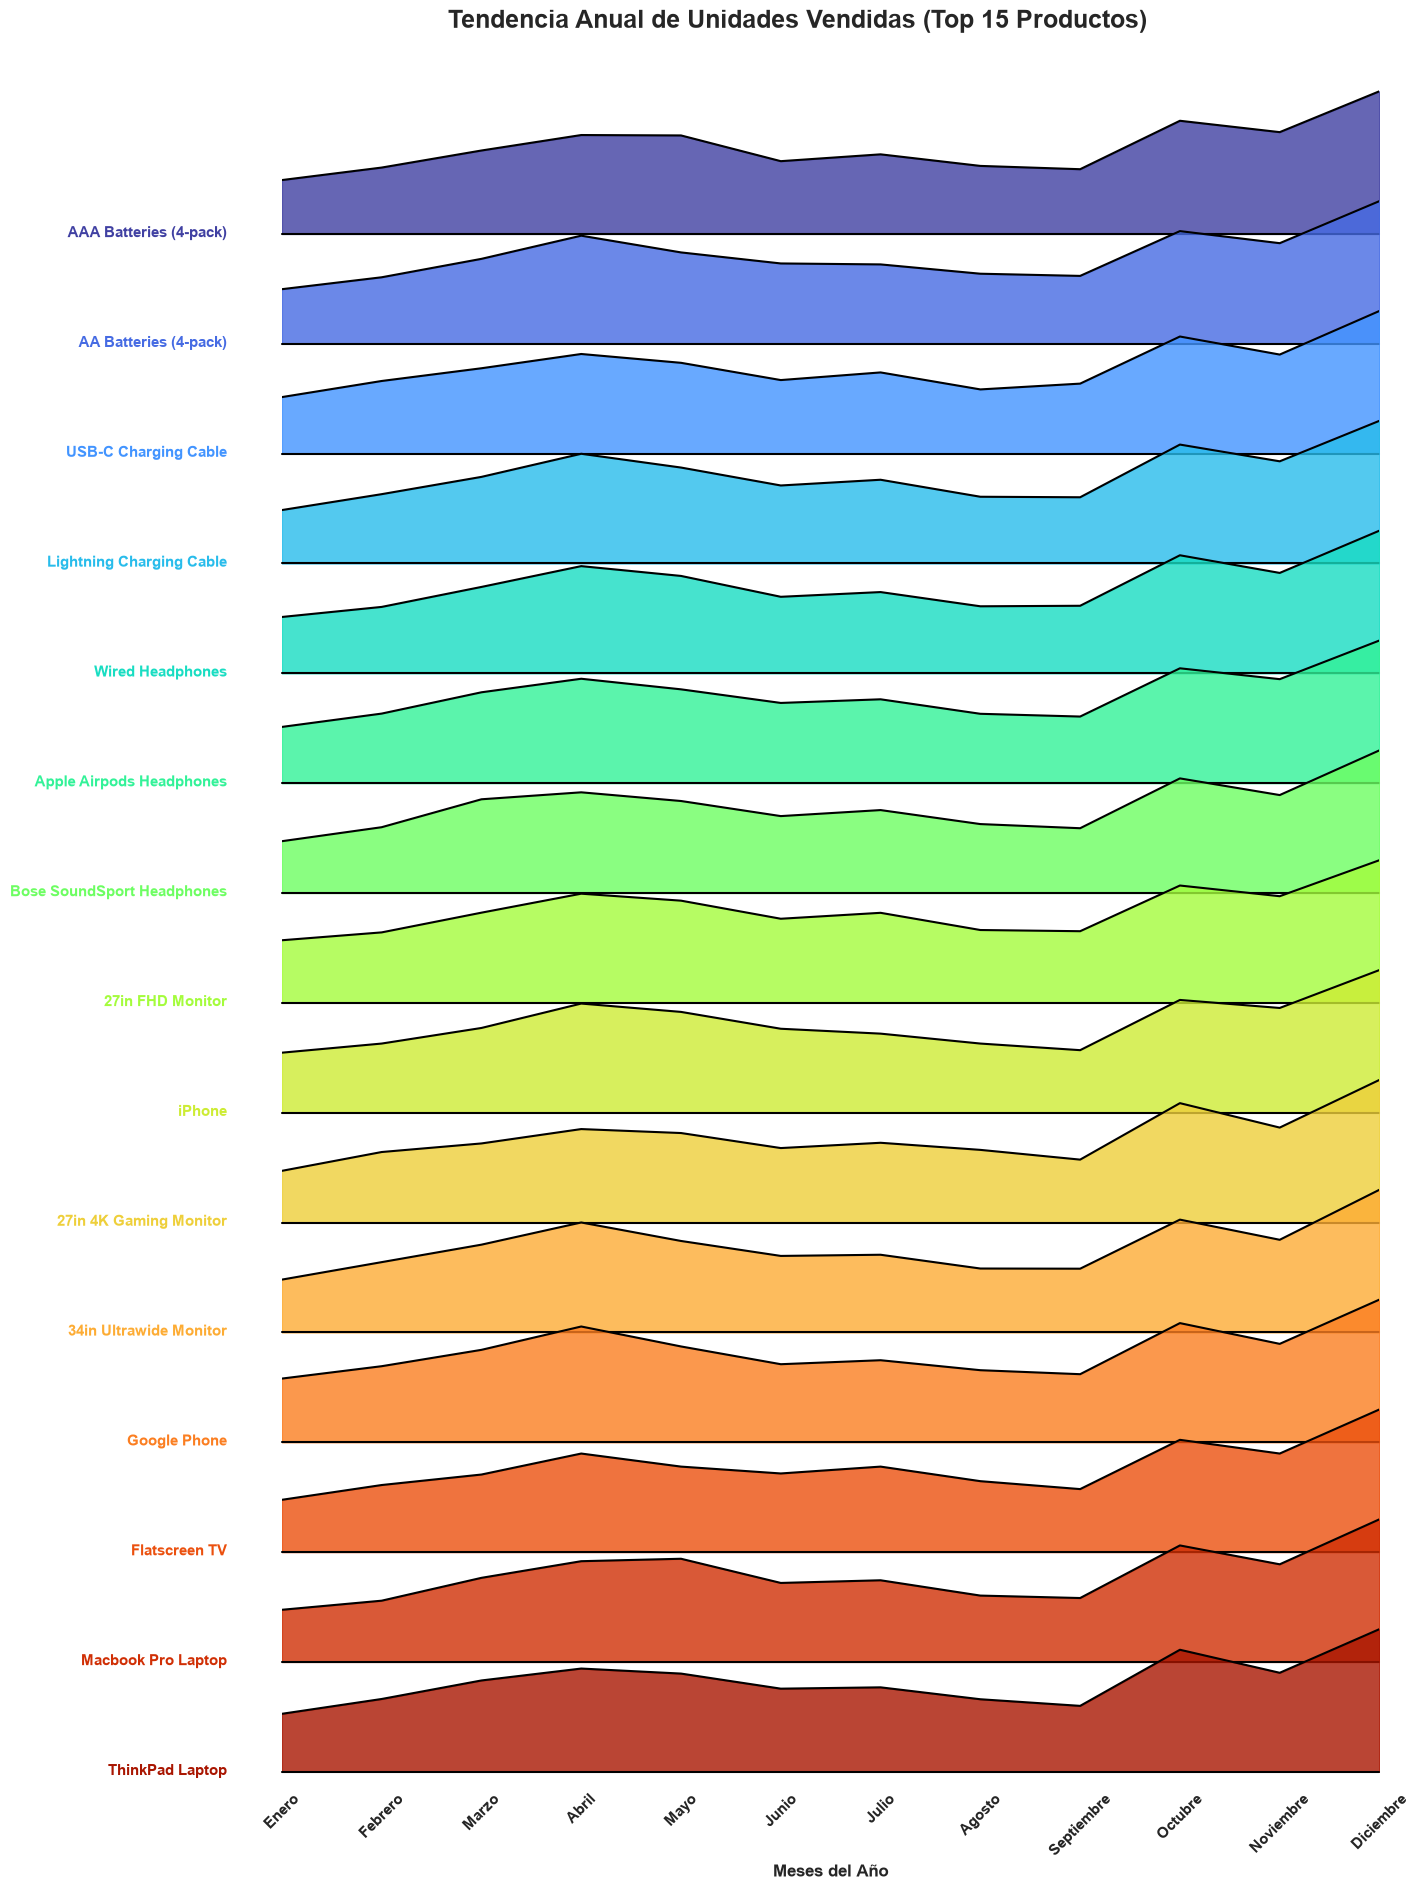

In [71]:



# Esto evita que el gráfico se vuelva demasiado alto y difícil de leer
top_15_productos = df.groupby('Producto')['Cantidad Pedida'].sum().nlargest(15).index
df_top = df[df['Producto'].isin(top_15_productos)]


df_tendencia_prod = df_top.groupby(['Producto', 'Mes'])['Cantidad Pedida'].sum().reset_index()

df_tendencia_prod['Producto'] = pd.Categorical(df_tendencia_prod['Producto'], categories=top_15_productos, ordered=True)
df_tendencia_prod = df_tendencia_prod.sort_values(['Producto', 'Mes'])


sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
paleta = sns.color_palette("turbo", len(top_15_productos))


g = sns.FacetGrid(df_tendencia_prod, row="Producto", hue="Producto", aspect=10, height=1.2, palette=paleta, sharey=False)

# efecto de cresta (línea + relleno)
def plot_area(x, y, color, **kwargs):
    ax = plt.gca()
    ax.plot(x, y, color="black", lw=1.5)
    ax.fill_between(x, y, color=color, alpha=0.8)

#  datos de Mes y Cantidad Pedida
g.map(plot_area, "Mes", "Cantidad Pedida")
g.map(plt.axhline, y=0, lw=1.5, clip_on=False, color="black")
g.figure.subplots_adjust(hspace=-0.3)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# nombre de cada producto 
for i, ax in enumerate(g.axes.flat):
    if i < len(top_15_productos):
        # Desplazamos un poco más a la izquierda (-0.05) porque los nombres de productos son largos
        ax.text(-0.05, 0.05, top_15_productos[i], fontweight='bold', fontsize=11,
                color=paleta[i], ha="right", va="center", transform=ax.transAxes)

# Título principal y configuración del eje X
g.figure.suptitle('Tendencia Anual de Unidades Vendidas (Top 15 Productos)', fontsize=18, fontweight='bold', y=1.02)

meses_nombres = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", 
                 "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
plt.xticks(range(1, 13), meses_nombres, rotation=45, fontsize=11, fontweight='bold')
plt.xlabel('Meses del Año', fontsize=12, fontweight='bold')

g.set(xlim=(1, 12))

plt.show()

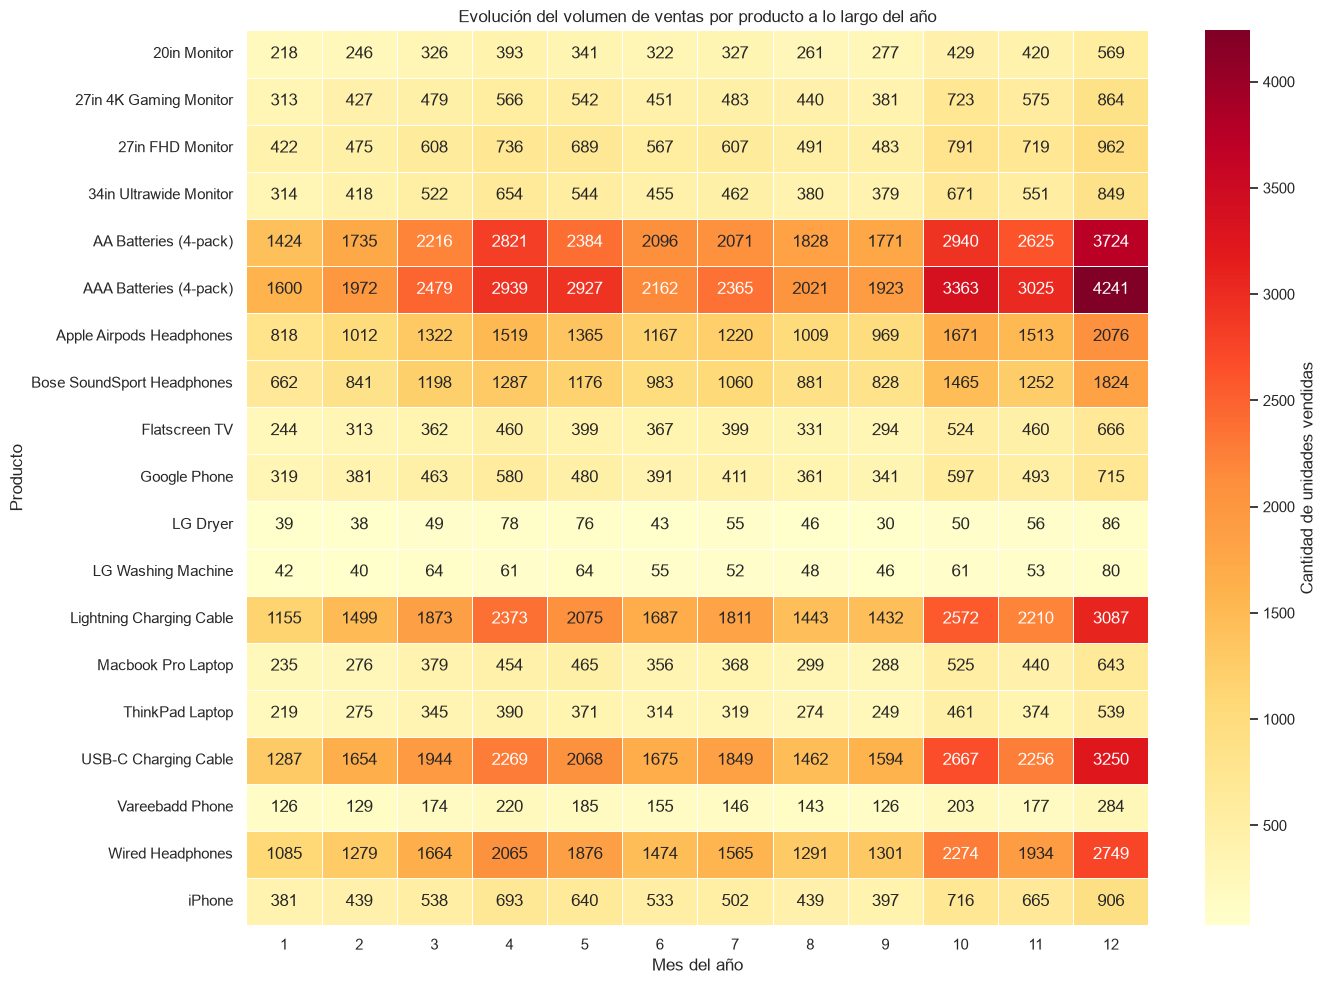

In [72]:


# Creamos la matriz pivote: Productos en filas, Meses en columnas
heatmap_productos = df.pivot_table(
    index="Producto",
    columns="Mes",
    values="Cantidad Pedida", 
    aggfunc="sum"             
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_productos,
    cmap="YlOrRd",      
    # prueba de colores: viridis, Blues, YlOrRd, 
    annot=True,
    fmt=".0f",          
    linewidths=0.5,     
    cbar_kws={'label': 'Cantidad de unidades vendidas'}
)

plt.xlabel("Mes del año")
plt.ylabel("Producto")
plt.title("Evolución del volumen de ventas por producto a lo largo del año")

plt.tight_layout()
plt.show()

### Precio vs Compras

In [ ]:

# Agrupamos por producto, obtenemos su precio y sumamos la cantidad pedida 
df_oferta = df.groupby('Producto').agg({
    'Precio Unitario': 'mean',
    'Cantidad Pedida': 'sum',
    'Venta': 'sum'
}).reset_index()

#  Ordenar del producto más caro al más barato 
df_oferta = df_oferta.sort_values(by='Precio Unitario', ascending=False)

# gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])


fig.add_trace(
    go.Bar(
        x=df_oferta['Producto'],
        y=df_oferta['Cantidad Pedida'],
        name="Unidades Vendidas (Demanda)",
        marker_color='#1E7EE4', # Azul corporativo elegante
        opacity=0.85
    ),
    secondary_y=False,
)

# 5. Añadir la línea para el Precio (Oferta)
fig.add_trace(
    go.Scatter(
        x=df_oferta['Producto'],
        y=df_oferta['Precio Unitario'],
        name="Precio Unitario ($)",
        mode='lines+markers',
        marker=dict(color='#E7100D', size=10), # Rojo vibrante para resaltar
        line=dict(width=3, shape='spline') # 'spline' suaviza la línea
    ),
    secondary_y=True,
)


fig.update_layout(
    title_text="Relación entre Precio del Producto y Unidades Vendidas",
    title_font=dict(size=22, color='#333333', family="Arial"),
    plot_bgcolor='rgba(245, 245, 245, 0.9)', 
    paper_bgcolor='white',
    hovermode="x unified", 
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    ),
    margin=dict(t=100, b=120)
)


fig.update_xaxes(title_text="<b>Productos</b> (Ordenados por Precio Descendente)", tickangle=45)
fig.update_yaxes(title_text="<b>Unidades Vendidas</b>", secondary_y=False, color='#1E7EE4')
fig.update_yaxes(title_text="<b>Precio Unitario (USD)</b>", secondary_y=True, color='#E7100D', tickprefix="$")


fig.show()

#### Precios vs Ventas

In [ ]:

# Agrupamos por producto, obtenemos su precio y sumamos la 'Venta' 
df_ingresos = df.groupby('Producto').agg({
    'Precio Unitario': 'mean',
    'Venta': 'sum'
}).reset_index()

# Ordenar del producto más caro al más barato
df_ingresos = df_ingresos.sort_values(by='Precio Unitario', ascending=False)

# Gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_ingresos['Producto'],
        y=df_ingresos['Venta'],
        name="Ingreso Total Generado (USD)",
        marker_color='#108D2B', 
        opacity=0.85
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_ingresos['Producto'],
        y=df_ingresos['Precio Unitario'],
        name="Precio Unitario ($)",
        mode='lines+markers',
        marker=dict(color='#E7100D', size=10), # Rojo vibrante
        line=dict(width=3, shape='spline')
    ),
    secondary_y=True,
)

fig.update_layout(
    title_text="Precio del Producto vs. Ingresos Totales Generados",
    title_font=dict(size=22, color='#333333', family="Arial"),
    plot_bgcolor='rgba(245, 245, 245, 0.9)',
    paper_bgcolor='white',
    hovermode="x unified", 
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    ),
    margin=dict(t=100, b=120)
)


fig.update_xaxes(title_text="<b>Productos</b> (Ordenados por Precio Descendente)", tickangle=45)

fig.update_yaxes(title_text="<b>Ingreso Total (USD)</b>", secondary_y=False, color='#108D2B', tickprefix="$")
fig.update_yaxes(title_text="<b>Precio Unitario (USD)</b>", secondary_y=True, color='#E7100D', tickprefix="$")

fig.show()

### Mapa de calor por importe de facturación

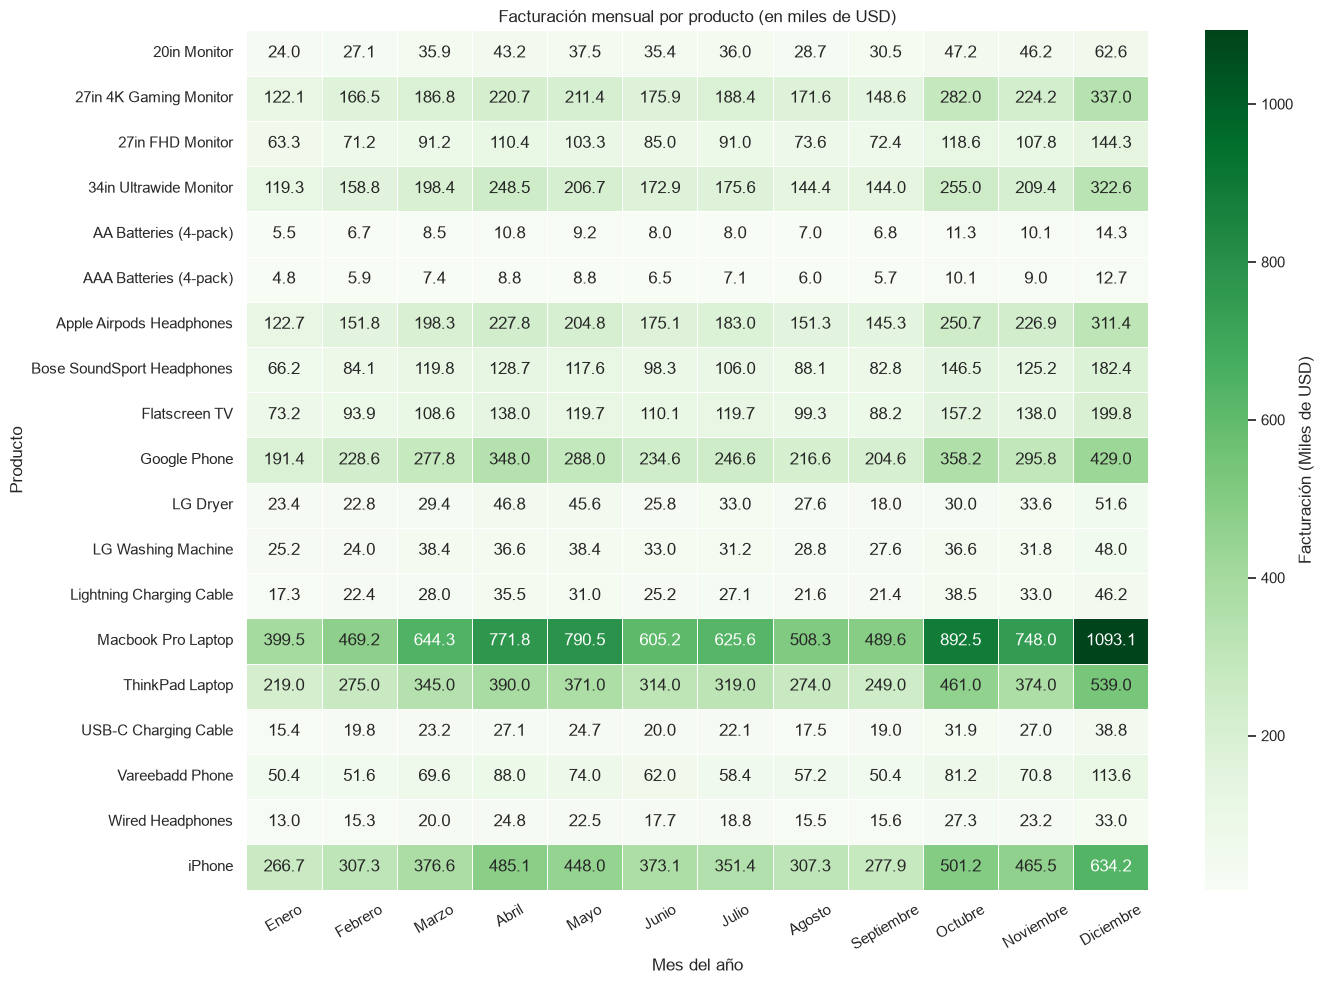

In [81]:
heatmap_ingresos_prod = df.pivot_table(
    index="Producto",
    columns="Mes",
    values="Venta",
    aggfunc="sum" 
)

heatmap_ingresos_prod_k = heatmap_ingresos_prod / 1000

# 3. Configuración del gráfico
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_ingresos_prod_k,
    cmap="Greens",           
    # viridis, Greens
    annot=True,
    fmt=".1f",               
    linewidths=0.5,
    cbar_kws={'label': 'Facturación (Miles de USD)'},
    xticklabels=MESES_NOMBRES
)
plt.xticks(rotation=30)
plt.xlabel("Mes del año")
plt.ylabel("Producto")
plt.title("Facturación mensual por producto (en miles de USD)")

plt.tight_layout()
plt.show()

### presentacion geografica

#### Coordenadas de las ciudades del dataset

In [134]:
coordenadas = {
    'Atlanta': (33.7490, -84.3880),
    'Austin': (30.2672, -97.7431),
    'Boston': (42.3601, -71.0589),
    'Dallas': (32.7767, -96.7970),
    'Los Angeles': (34.0522, -118.2437),
    'New York City': (40.7128, -74.0060),
    'Portland': (45.5152, -122.6784), 
    'San Francisco': (37.7749, -122.4194),
    'Seattle': (47.6062, -122.3321)
}

In [138]:
ciudades_geo = pd.DataFrame({
    'Ciudad': list(coordenadas.keys()),
    'Latitud': [v[0] for v in coordenadas.values()],
    'Longitud': [v[1] for v in coordenadas.values()]
})

fig = px.scatter_geo(
    ciudades_geo,
    lat='Latitud',
    lon='Longitud',
    text='Ciudad',          
    scope='usa',
    title='Distribución Geográfica y Área de Influencia Comercial'
)

# Configuramos cómo se ven los textos y los puntos
fig.update_traces(
    marker=dict(size=14, color='#d62728', line=dict(width=2, color='white')),
    textposition='top center',      
    textfont=dict(size=12, color='#333333', family='Arial')
)

fig.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    geo=dict(
        landcolor='#f7f7f7',
        lakecolor='#cce5ff',
        showlakes=True,
        countrycolor='#cccccc',
        showcountries=True,
        showcoastlines=True,
        bgcolor='#eaf4fb'
    )
)

fig.show()

In [ ]:
ventas_por_ciudad = df.groupby('Ciudad')['Venta'].sum().reset_index()

# coordenadas para las ciudades principales del dataset



# Mapear las coordenadas al dataframe agrupado
ventas_por_ciudad['Latitud'] = ventas_por_ciudad['Ciudad'].map(lambda x: coordenadas.get(x, (0,0))[0])
ventas_por_ciudad['Longitud'] = ventas_por_ciudad['Ciudad'].map(lambda x: coordenadas.get(x, (0,0))[1])

# Filtrar ubicaciones sin coordenadas válidas
ventas_por_ciudad = ventas_por_ciudad[ventas_por_ciudad['Latitud'] != 0]

# Crear el gráfico de mapa de burbujas (Scatter Geo)
fig = px.scatter_geo(
    ventas_por_ciudad, 
    lat='Latitud', 
    lon='Longitud', 
    size='Venta',         
    color='Venta',        
    hover_name='Ciudad',  
    scope="usa",          
    color_continuous_scale="Reds",
    title="Facturación Total por Ciudad (USD)"
)


fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    geo=dict(landcolor='lightgray', lakecolor='white') 
)

fig.show()

### días de la semana

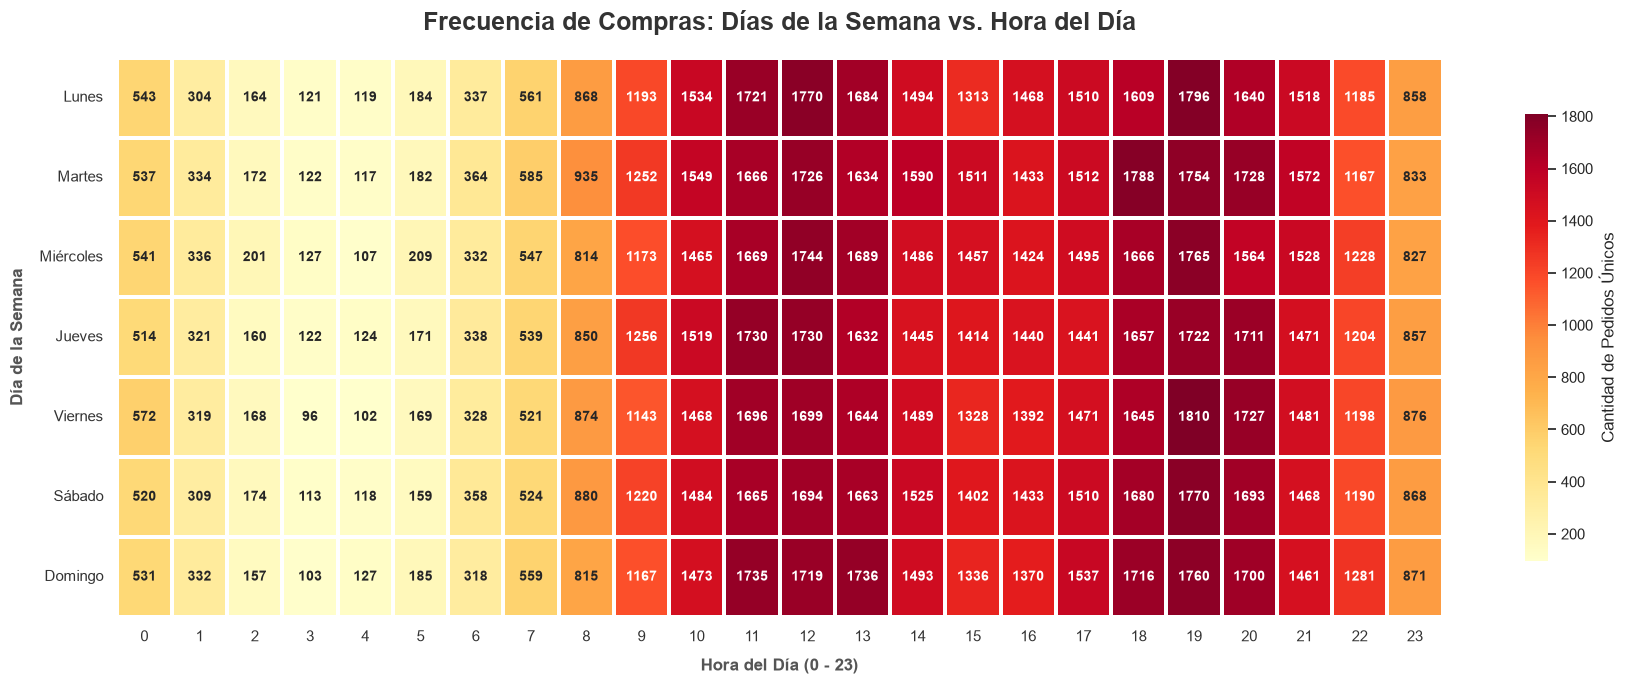

In [84]:
# Extracción de fecha y hora
df['Mes'] = df['Fecha de Pedido'].dt.month
df['Dia'] = df['Fecha de Pedido'].dt.day
df['Hora'] = df['Fecha de Pedido'].dt.hour
df['Ciudad'] = df['Dirección de Envio'].apply(lambda x: str(x).split(',')[1].strip())
df['Venta'] = df['Cantidad Pedida'] * df['Precio Unitario']


df["dia_semana"] = df["Fecha de Pedido"].dt.day_name().map(dias_es)


orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
df["dia_semana"] = pd.Categorical(df["dia_semana"], categories=orden_dias, ordered=True)

heatmap_dias = df.pivot_table(
    index="dia_semana", 
    columns="Hora", 
    values="ID de Pedido", 
    aggfunc="nunique", 
    fill_value=0
)

# subplot
fig, ax = plt.subplots(figsize=(18, 7), facecolor='#FFFFFF')

sns.heatmap(
    heatmap_dias, 
    cmap="YlOrRd", 
    annot=True, 
    fmt="d",              
    linewidths=1.5,        
    linecolor='#FFFFFF',   
    cbar_kws={'label': 'Cantidad de Pedidos Únicos', 'shrink': 0.8},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)


ax.set_title('Frecuencia de Compras: Días de la Semana vs. Hora del Día', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Hora del Día (0 - 23)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Día de la Semana', fontsize=12, fontweight='bold', labelpad=10, color='#555555')


ax.tick_params(axis='x', colors='#333333', labelsize=11)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

### Días del mes

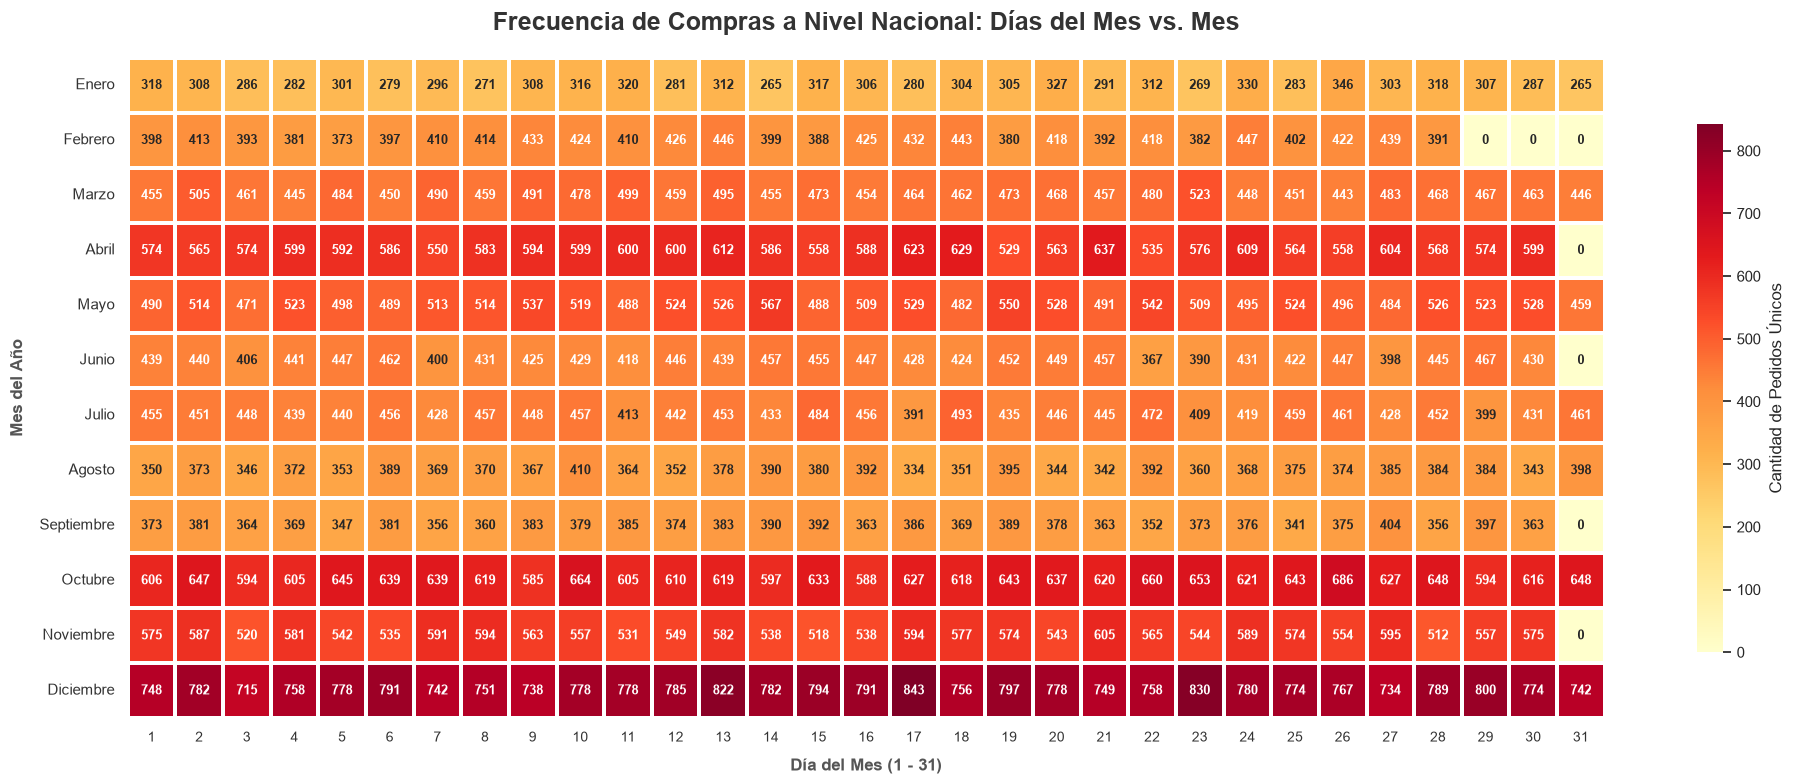

In [169]:


#  Crear un diccionario 
meses_dict = dict(zip(range(1, 13), MESES_NOMBRES))


df['Mes_Nombre'] = df['Mes'].map(meses_dict)

# Ordenar las categorías para el gráfico usando directamente tu lista
df['Mes_Nombre'] = pd.Categorical(df['Mes_Nombre'], categories=MESES_NOMBRES, ordered=True)


heatmap_dias_mes = df.pivot_table(
    index="Mes_Nombre",     
    columns="Dia",          
    values="ID de Pedido", 
    aggfunc="nunique",      
    fill_value=0
)


fig, ax = plt.subplots(figsize=(20, 8), facecolor='#FFFFFF')

sns.heatmap(
    heatmap_dias_mes, 
    cmap="YlOrRd", 
    annot=True, 
    fmt="d",              
    linewidths=1.5,        
    linecolor='#FFFFFF',   
    cbar_kws={'label': 'Cantidad de Pedidos Únicos', 'shrink': 0.8},
    annot_kws={"size": 9, "weight": "bold"},
    ax=ax
)


ax.set_title('Frecuencia de Compras a Nivel Nacional: Días del Mes vs. Mes', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Día del Mes (1 - 31)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Mes del Año', fontsize=12, fontweight='bold', labelpad=10, color='#555555')

ax.tick_params(axis='x', colors='#333333', labelsize=10)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

### Combos más comprados

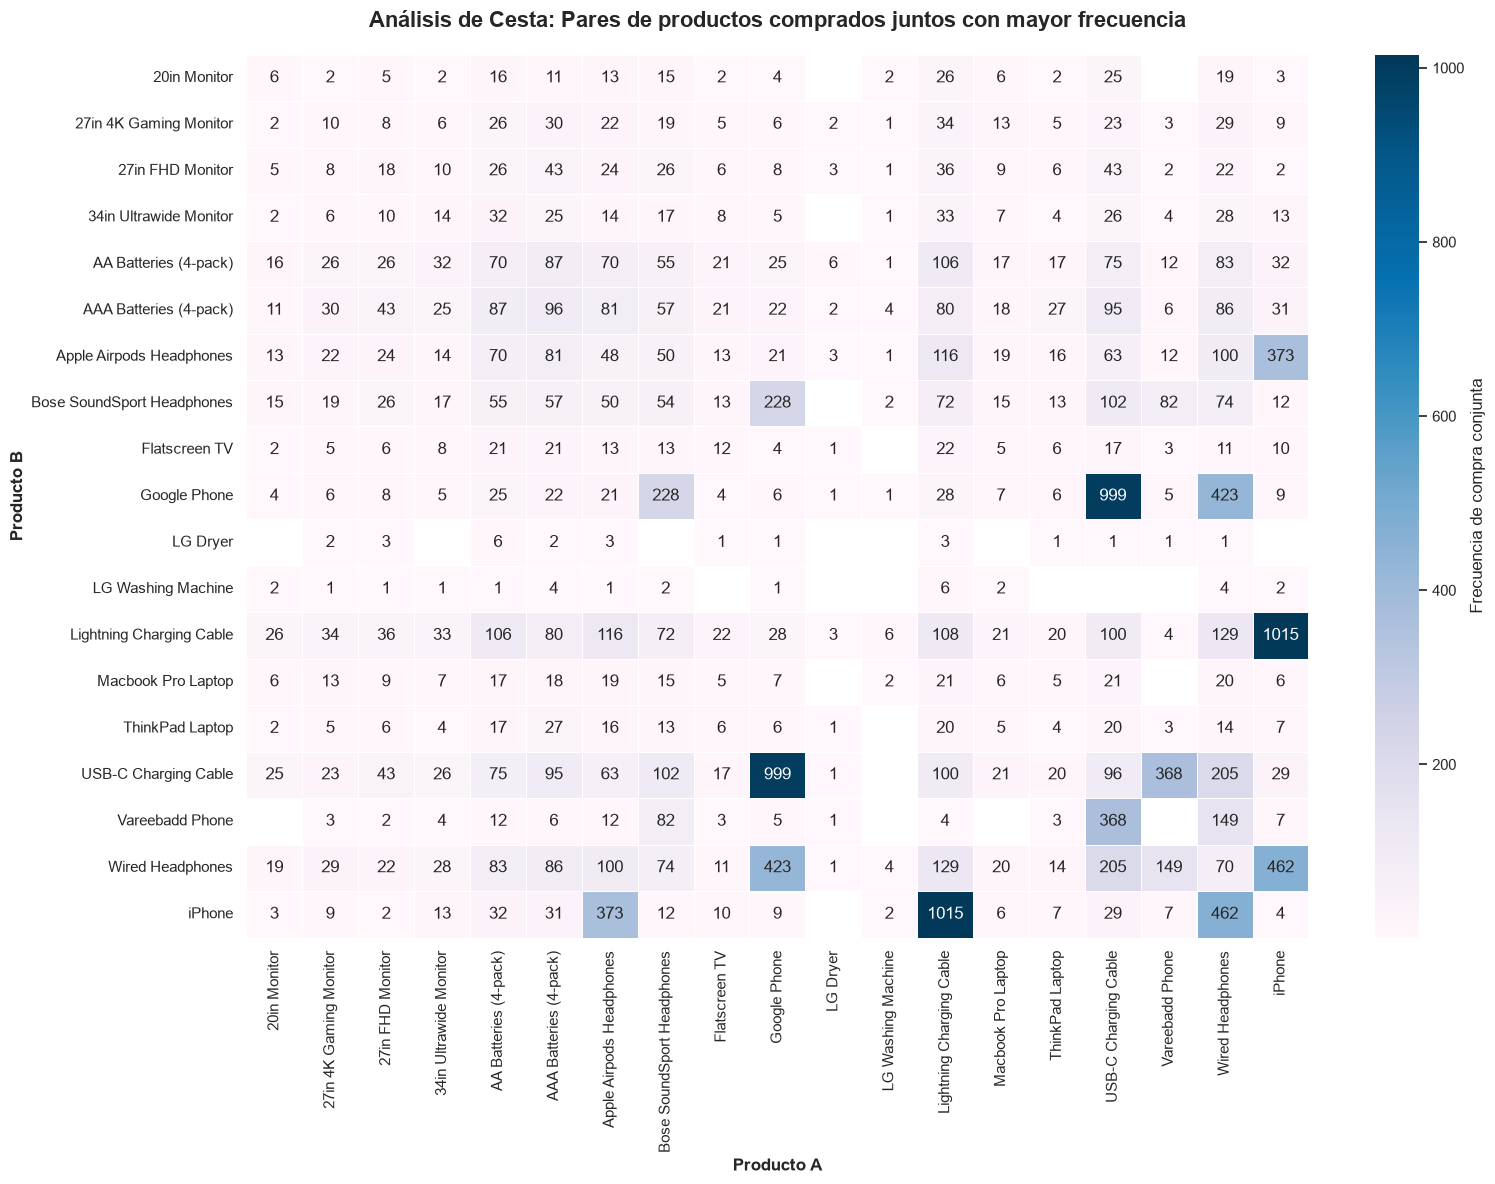

In [85]:


# Filtramos solo los pedidos que tienen más de un producto
df_multi = df[df['ID de Pedido'].duplicated(keep=False)]

# Agrupamos los productos por cada 'ID de Pedido' en una lista
pedidos_agrupados = df_multi.groupby('ID de Pedido')['Producto'].apply(list)

# Generamos y contamos los pares posibles
contador_pares = Counter()

for productos in pedidos_agrupados:
    productos_ordenados = sorted(productos)
    contador_pares.update(combinations(productos_ordenados, 2))


productos_unicos = sorted(list(set([prod for par in contador_pares.keys() for prod in par])))

# Creamos un DataFrame vacío lleno de ceros
matriz_pares = pd.DataFrame(0, index=productos_unicos, columns=productos_unicos)

# Llenamos el DataFrame con los conteos
for (prod1, prod2), cantidad in contador_pares.items():
    matriz_pares.loc[prod1, prod2] += cantidad
    matriz_pares.loc[prod2, prod1] += cantidad  
# 5. Generamos el Heatmap
plt.figure(figsize=(16, 12))

# Opcional: Creamos una máscara para ocultar la diagonal principal y los valores 0
# Esto reduce el "ruido" visual y deja ver solo los cruces reales
mascara = matriz_pares == 0 

sns.heatmap(
    matriz_pares, 
    cmap="PuBu",         # Tonos púrpuras/azules para destacar las ventas
    annot=True,          # Mostramos el número exacto
    fmt="d",             # Formato numérico entero
    linewidths=0.5, 
    mask=mascara,        # Aplicamos la máscara
    cbar_kws={'label': 'Frecuencia de compra conjunta'}
)

plt.title("Análisis de Cesta: Pares de productos comprados juntos con mayor frecuencia", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Producto A", fontsize=12, fontweight='bold')
plt.ylabel("Producto B", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

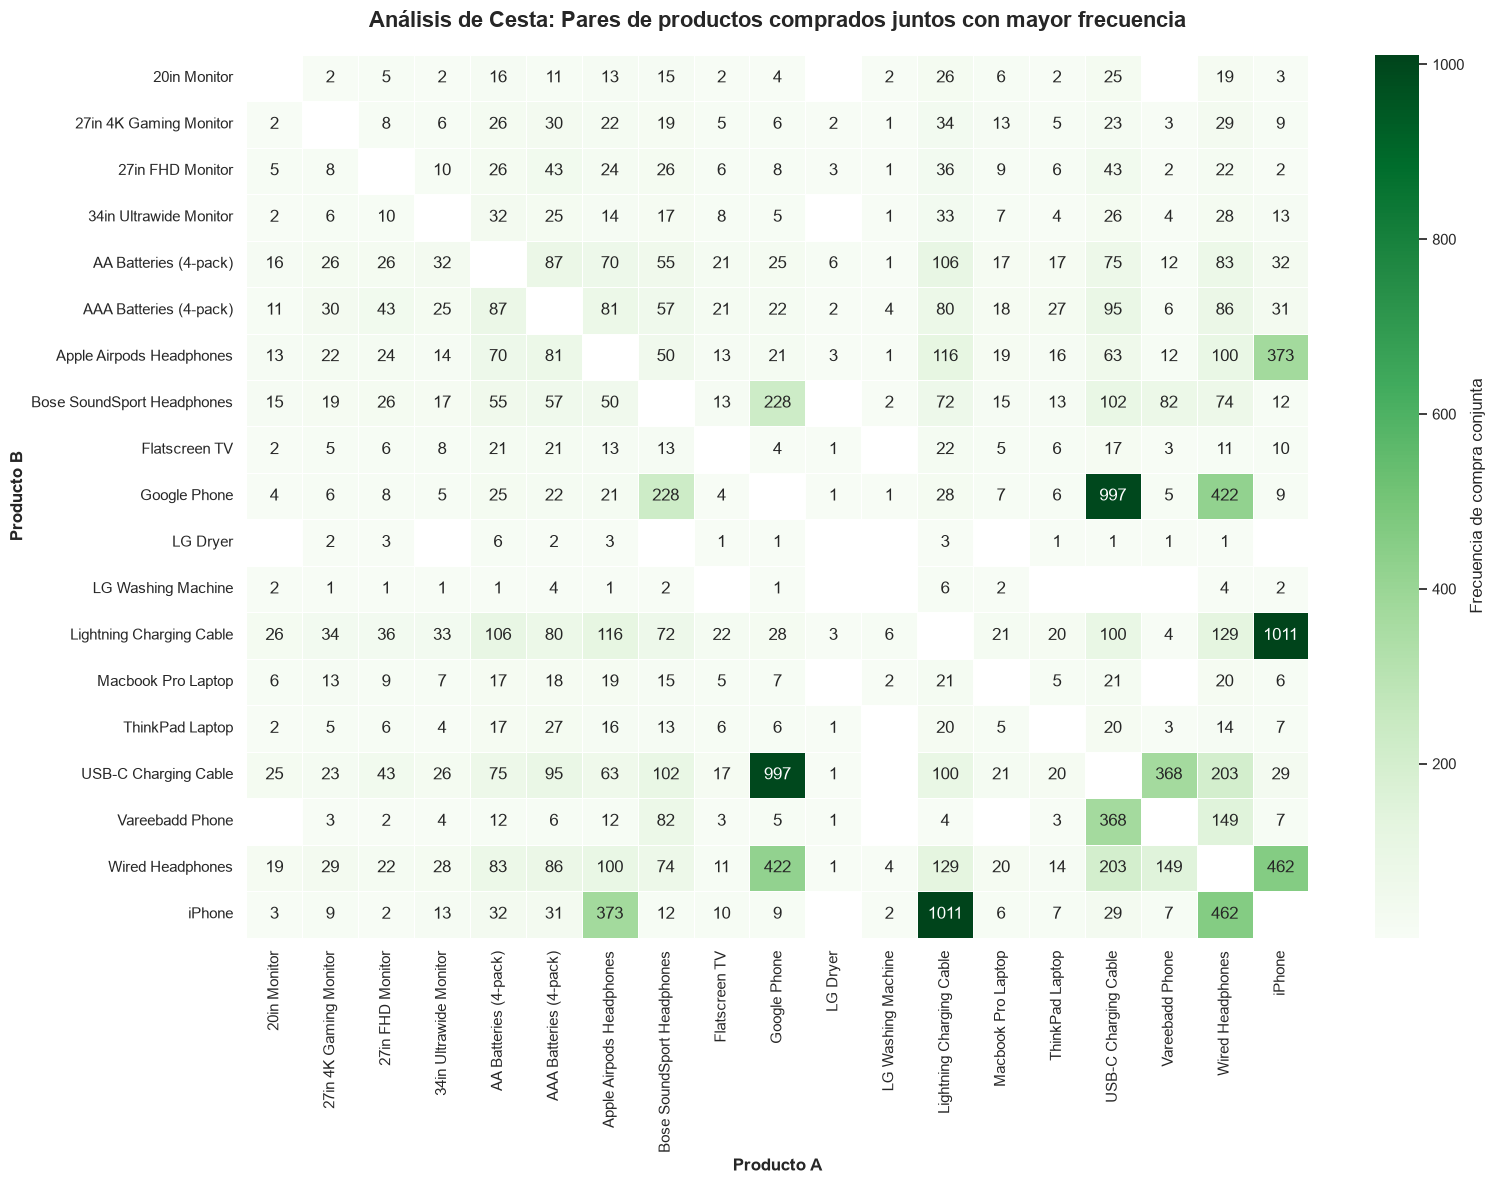

In [91]:
#from collections import Counter
#from itertools import combinations
#import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns

# Filtramos solo los pedidos que tienen más de un producto
df_multi = df[df['ID de Pedido'].duplicated(keep=False)]

pedidos_agrupados = df_multi.groupby('ID de Pedido')['Producto'].apply(lambda x: list(set(x)))

# Generamos y contamos los pares posibles
contador_pares = Counter()

for productos in pedidos_agrupados:
    productos_ordenados = sorted(productos)
    
    if len(productos_ordenados) >= 2:
        contador_pares.update(combinations(productos_ordenados, 2))


registros = []
for (prod1, prod2), cantidad in contador_pares.items():
    registros.append({'Producto A': prod1, 'Producto B': prod2, 'Cantidad': cantidad})
      
    if prod1 != prod2:
        registros.append({'Producto A': prod2, 'Producto B': prod1, 'Cantidad': cantidad})


df_frecuencias = pd.DataFrame(registros)
matriz_pares = df_frecuencias.pivot_table(
    index='Producto A', 
    columns='Producto B', 
    values='Cantidad', 
    aggfunc='sum'
)


matriz_pares = matriz_pares.fillna(0).astype(int)

plt.figure(figsize=(16, 12))


mascara = matriz_pares == 0 

sns.heatmap(
    matriz_pares, 
    cmap="Greens",  
    # PuBu, Turbo       
    annot=True,         
    fmt="d",             
    linewidths=0.5, 
    mask=mascara,        
    cbar_kws={'label': 'Frecuencia de compra conjunta'}
)

plt.title("Análisis de Cesta: Pares de productos comprados juntos con mayor frecuencia", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Producto A", fontsize=12, fontweight='bold')
plt.ylabel("Producto B", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Brenda\AppData\Local\Temp\ipykernel_26188\3577253534.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=frecuencias, y=combos, palette="Blues_r", edgecolor=".2")


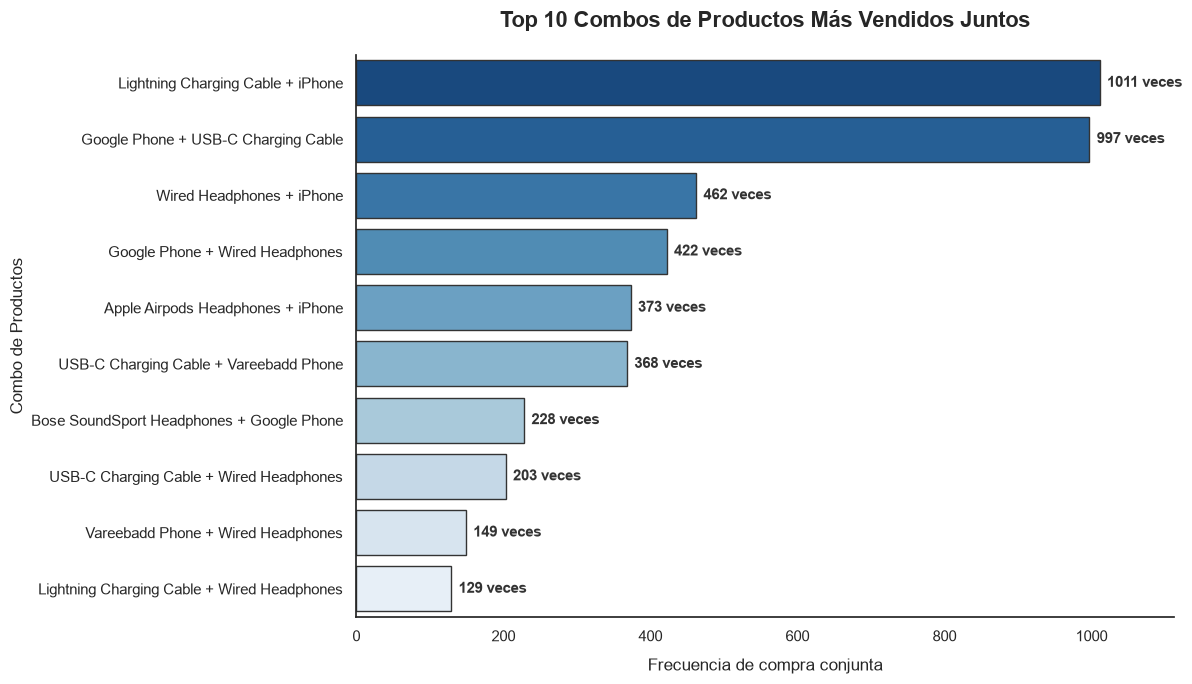

In [94]:
# Filtramos pedidos múltiples y evitamos productos duplicados en el mismo pedido
df_multi = df[df['ID de Pedido'].duplicated(keep=False)]
pedidos_agrupados = df_multi.groupby('ID de Pedido')['Producto'].apply(lambda x: list(set(x)))

# Contamos las combinaciones de 2 productos
contador_pares = Counter()
for productos in pedidos_agrupados:
    productos_ordenados = sorted(productos)
    if len(productos_ordenados) >= 2:
        contador_pares.update(combinations(productos_ordenados, 2))

# Obtenemos específicamente los 10 combos más vendidos
top_10_combos = contador_pares.most_common(10)

# Preparamos listas separadas para el gráfico
combos = [" + ".join(par) for par, cantidad in top_10_combos]
frecuencias = [cantidad for par, cantidad in top_10_combos]


plt.figure(figsize=(12, 7))


ax = sns.barplot(x=frecuencias, y=combos, palette="Blues_r", edgecolor=".2")


for index, value in enumerate(frecuencias):
    ax.text(value + 10, index, f'{value} veces', color='#333333', va='center', fontweight='bold', fontsize=11)


plt.title("Top 10 Combos de Productos Más Vendidos Juntos", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Frecuencia de compra conjunta", fontsize=12, labelpad=10)
plt.ylabel("Combo de Productos", fontsize=12)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(0, max(frecuencias) * 1.10) 

plt.tight_layout()
plt.show()

## Medidas de Tendencia Central

Media (Promedio): $193.30
Mediana: $14.95
Moda: $14.95


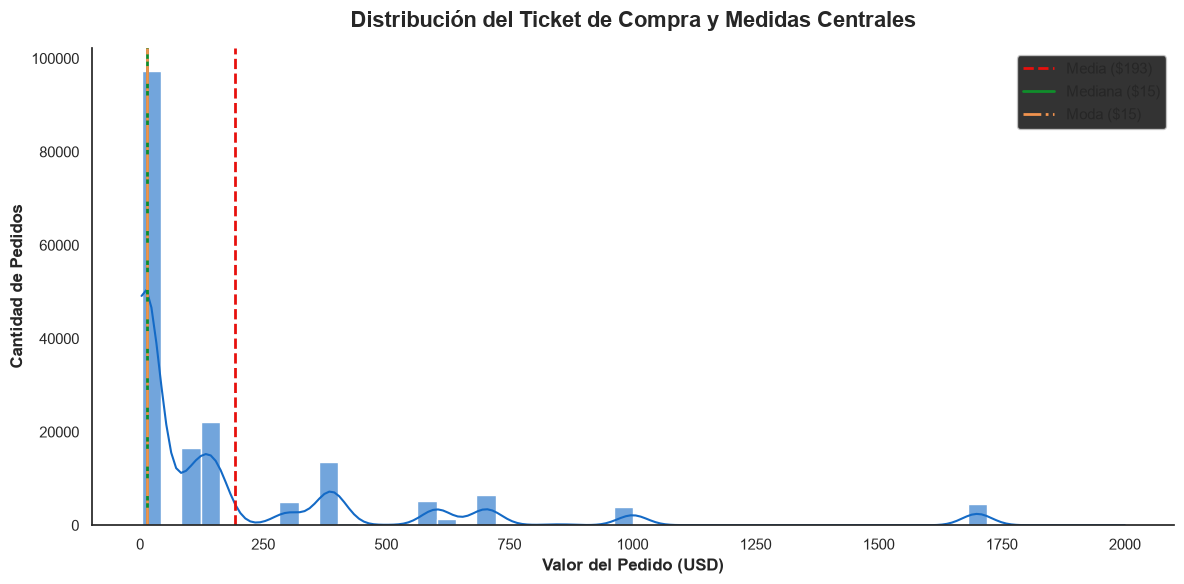

In [95]:
#  total facturado por cada pedido único
facturacion_pedidos = df.groupby('ID de Pedido')['Venta'].sum()

# Calculamos las métricas estadísticas
media = facturacion_pedidos.mean()
mediana = facturacion_pedidos.median()
moda = facturacion_pedidos.mode()[0] 

print(f"Media (Promedio): ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Moda: ${moda:.2f}")

# gráfico de distribución
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#FFFFFF')

# Histograma de facturacion
sns.histplot(facturacion_pedidos[facturacion_pedidos < 2000], 
             bins=50, kde=True, color="#146AC6", alpha=0.6, ax=ax)
ax.axvline(media, color='#E7100D', linestyle='--', linewidth=2, label=f'Media (${media:.0f})')
ax.axvline(mediana, color='#108D2B', linestyle='-', linewidth=2, label=f'Mediana (${mediana:.0f})')
ax.axvline(moda, color='#F1934E', linestyle='-.', linewidth=2, label=f'Moda (${moda:.0f})')

ax.set_title('Distribución del Ticket de Compra y Medidas Centrales', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Valor del Pedido (USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Pedidos', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

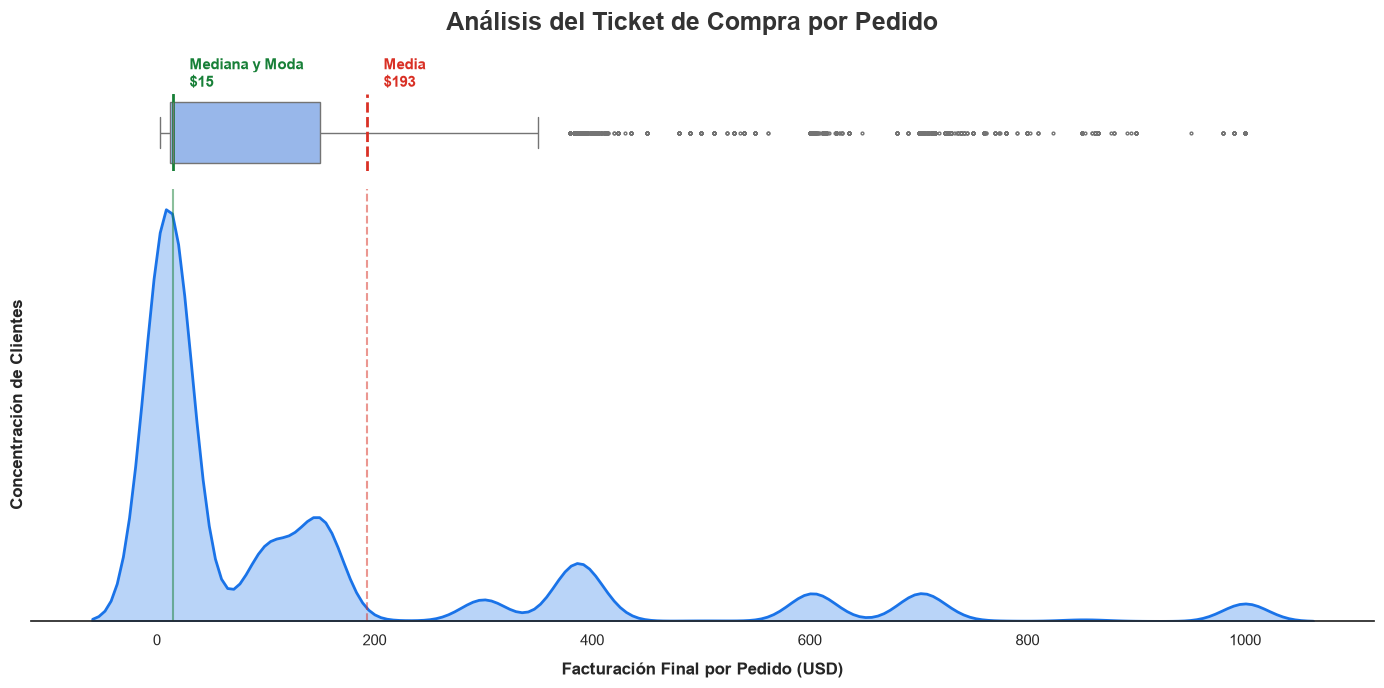

In [96]:

facturacion_pedidos = df.groupby('ID de Pedido')['Venta'].sum()
media = facturacion_pedidos.mean()
mediana = facturacion_pedidos.median()
# Tomamos el primer valor de la moda
moda = facturacion_pedidos.mode()[0] 


datos_visuales = facturacion_pedidos[facturacion_pedidos <= 1000]


fig, (ax_box, ax_dist) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(14, 7), 
    sharex=True, 
    gridspec_kw={"height_ratios": [0.15, 0.85]}, 
    facecolor='#FFFFFF'
)


sns.boxplot(x=datos_visuales, ax=ax_box, color="#8ab4f8", fliersize=2)
ax_box.set_xlabel('')
ax_box.set_yticks([])


ax_box.axvline(media, color='#d93025', linestyle='--', lw=2)
ax_box.text(media + 15, -0.6, f"Media\n${media:.0f}", color='#d93025', fontweight='bold', fontsize=11)


ax_box.axvline(mediana, color='#188038', linestyle='-', lw=2)
ax_box.text(mediana + 15, -0.6, f"Mediana y Moda\n${mediana:.0f}", color='#188038', fontweight='bold', fontsize=11)


ax_box.spines['top'].set_visible(False)
ax_box.spines['right'].set_visible(False)
ax_box.spines['left'].set_visible(False)
ax_box.spines['bottom'].set_visible(False)



sns.kdeplot(datos_visuales, fill=True, color="#1a73e8", alpha=0.3, linewidth=2, ax=ax_dist)


ax_dist.axvline(media, color='#d93025', linestyle='--', lw=1.5, alpha=0.5)
ax_dist.axvline(mediana, color='#188038', linestyle='-', lw=1.5, alpha=0.5)

# Títulos y Ejes
fig.suptitle('Análisis del Ticket de Compra por Pedido', fontsize=18, fontweight='bold', y=0.98, color='#333333')
ax_dist.set_xlabel('Facturación Final por Pedido (USD)', fontsize=12, fontweight='bold', labelpad=10)
ax_dist.set_ylabel('Concentración de Clientes', fontsize=12, fontweight='bold')

# Ocultamos los números del eje Y (la densidad estorba a nivel visual para negocios)
ax_dist.set_yticks([]) 
sns.despine(ax=ax_dist, left=True)

plt.tight_layout()
plt.show()

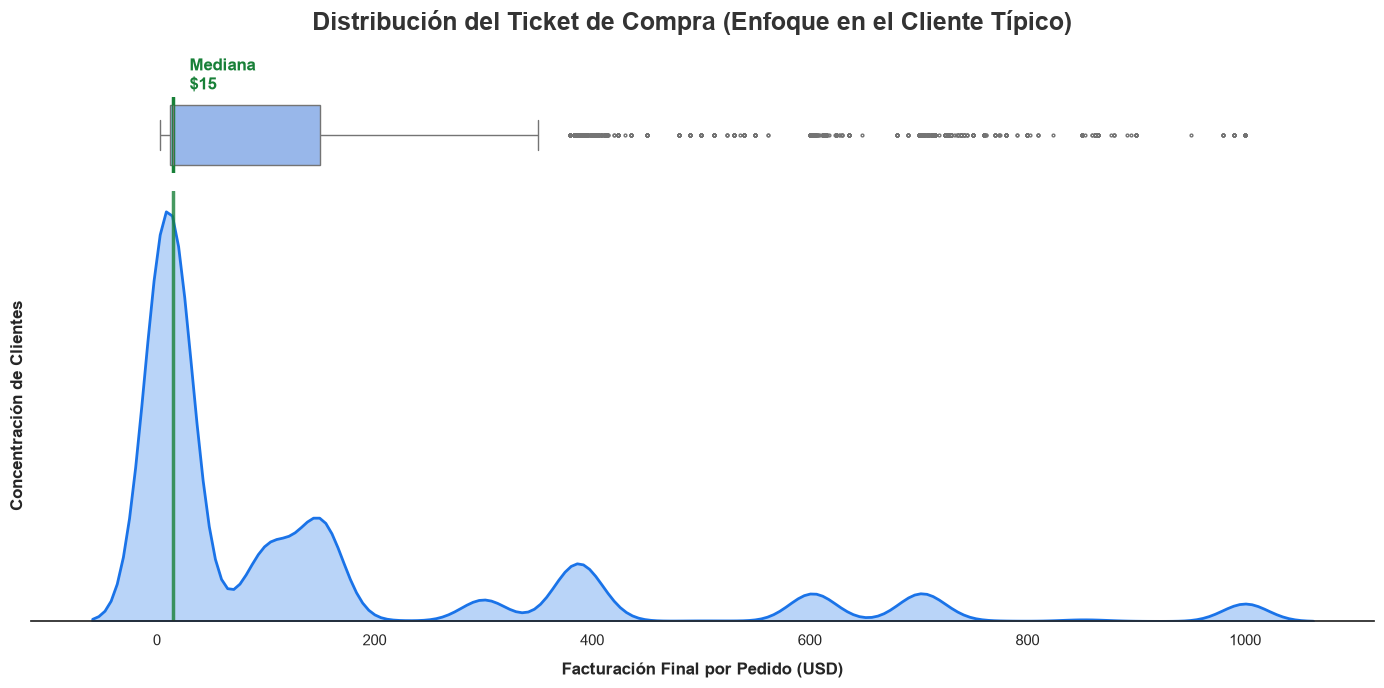

In [97]:


# 1. Calculamos la facturación por pedido y únicamente la mediana
facturacion_pedidos = df.groupby('ID de Pedido')['Venta'].sum()
mediana = facturacion_pedidos.median()

# Filtramos visualmente los valores atípicos extremos para que la curva se vea bien definida
# (El 99% de las ventas ocurren por debajo de los $1000)
datos_visuales = facturacion_pedidos[facturacion_pedidos <= 1000]

# 2. Configurar layout dividido: Boxplot (Arriba) y Curva de Densidad (Abajo)
fig, (ax_box, ax_dist) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(14, 7), 
    sharex=True, 
    gridspec_kw={"height_ratios": [0.15, 0.85]}, 
    facecolor='#FFFFFF'
)

# --- PANEL SUPERIOR: Boxplot ---
sns.boxplot(x=datos_visuales, ax=ax_box, color="#8ab4f8", fliersize=2)
ax_box.set_xlabel('')
ax_box.set_yticks([])

# Etiqueta y línea exclusiva para la Mediana
ax_box.axvline(mediana, color='#188038', linestyle='-', lw=2.5)
ax_box.text(mediana + 15, -0.6, f"Mediana\n${mediana:.0f}", color='#188038', fontweight='bold', fontsize=12)

# Limpieza del marco superior
ax_box.spines['top'].set_visible(False)
ax_box.spines['right'].set_visible(False)
ax_box.spines['left'].set_visible(False)
ax_box.spines['bottom'].set_visible(False)


# --- PANEL INFERIOR: Distribución suave ---
sns.kdeplot(datos_visuales, fill=True, color="#1a73e8", alpha=0.3, linewidth=2, ax=ax_dist)

# Proyectamos la línea de la mediana hacia abajo para conectar con la masa de clientes
ax_dist.axvline(mediana, color='#188038', linestyle='-', lw=2.5, alpha=0.8)

# Títulos y Ejes
fig.suptitle('Distribución del Ticket de Compra (Enfoque en el Cliente Típico)', fontsize=18, fontweight='bold', y=0.98, color='#333333')
ax_dist.set_xlabel('Facturación Final por Pedido (USD)', fontsize=12, fontweight='bold', labelpad=10)
ax_dist.set_ylabel('Concentración de Clientes', fontsize=12, fontweight='bold')

# Ocultamos los números del eje Y para reducir la carga cognitiva
ax_dist.set_yticks([]) 
sns.despine(ax=ax_dist, left=True)

plt.tight_layout()
plt.show()

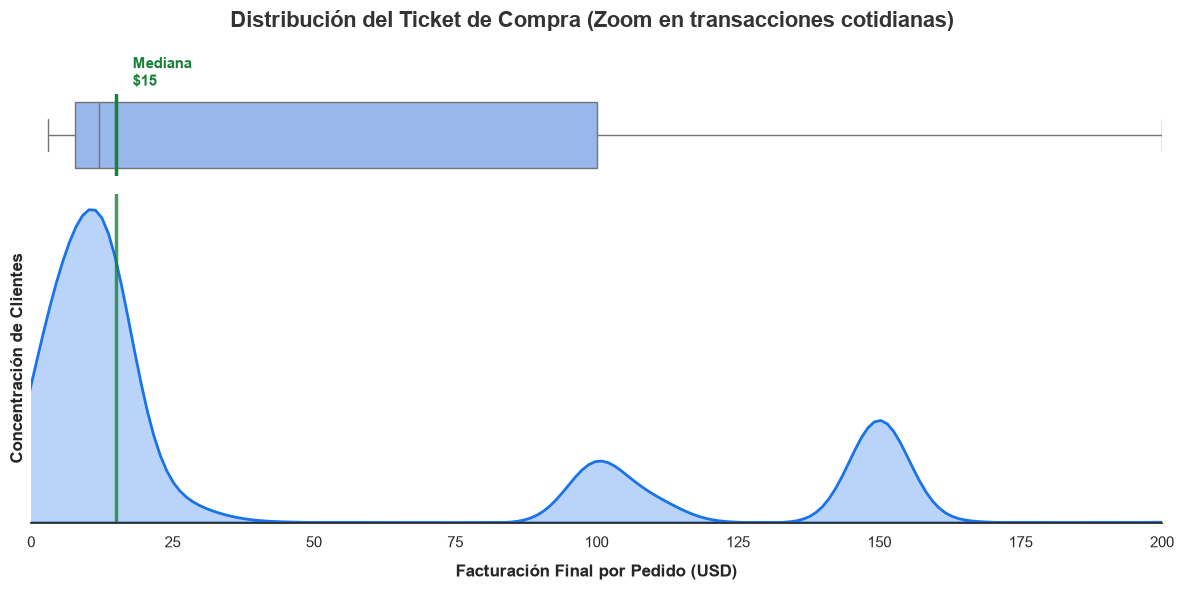

In [99]:

# Calculamos la facturación real y la mediana con el dataset completo
facturacion_pedidos = df.groupby('ID de Pedido')['Venta'].sum()
mediana = facturacion_pedidos.median()


limite_visual = 200
datos_zoom = facturacion_pedidos[facturacion_pedidos <= limite_visual]

fig, (ax_box, ax_dist) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(12, 6), 
    sharex=True, 
    gridspec_kw={"height_ratios": [0.2, 0.8]}, 
    facecolor='#FFFFFF'
)


sns.boxplot(x=datos_zoom, ax=ax_box, color="#8ab4f8", fliersize=4)
ax_box.set_xlabel('')
ax_box.set_yticks([])


ax_box.axvline(mediana, color='#188038', linestyle='-', lw=2.5)
ax_box.text(mediana + 3, -0.6, f"Mediana\n${mediana:.0f}", color='#188038', fontweight='bold', fontsize=11)

sns.despine(ax=ax_box, left=True, bottom=True)

sns.kdeplot(datos_zoom, fill=True, color="#1a73e8", alpha=0.3, linewidth=2, ax=ax_dist)
ax_dist.axvline(mediana, color='#188038', linestyle='-', lw=2.5, alpha=0.8)

fig.suptitle('Distribución del Ticket de Compra (Zoom en transacciones cotidianas)', fontsize=16, fontweight='bold', color='#333333')
ax_dist.set_xlabel('Facturación Final por Pedido (USD)', fontsize=12, fontweight='bold', labelpad=10)
ax_dist.set_ylabel('Concentración de Clientes', fontsize=12, fontweight='bold')

ax_dist.set_xlim(0, limite_visual)
ax_dist.set_yticks([]) 
sns.despine(ax=ax_dist, left=True)

plt.tight_layout()
plt.show()

## Dashboard

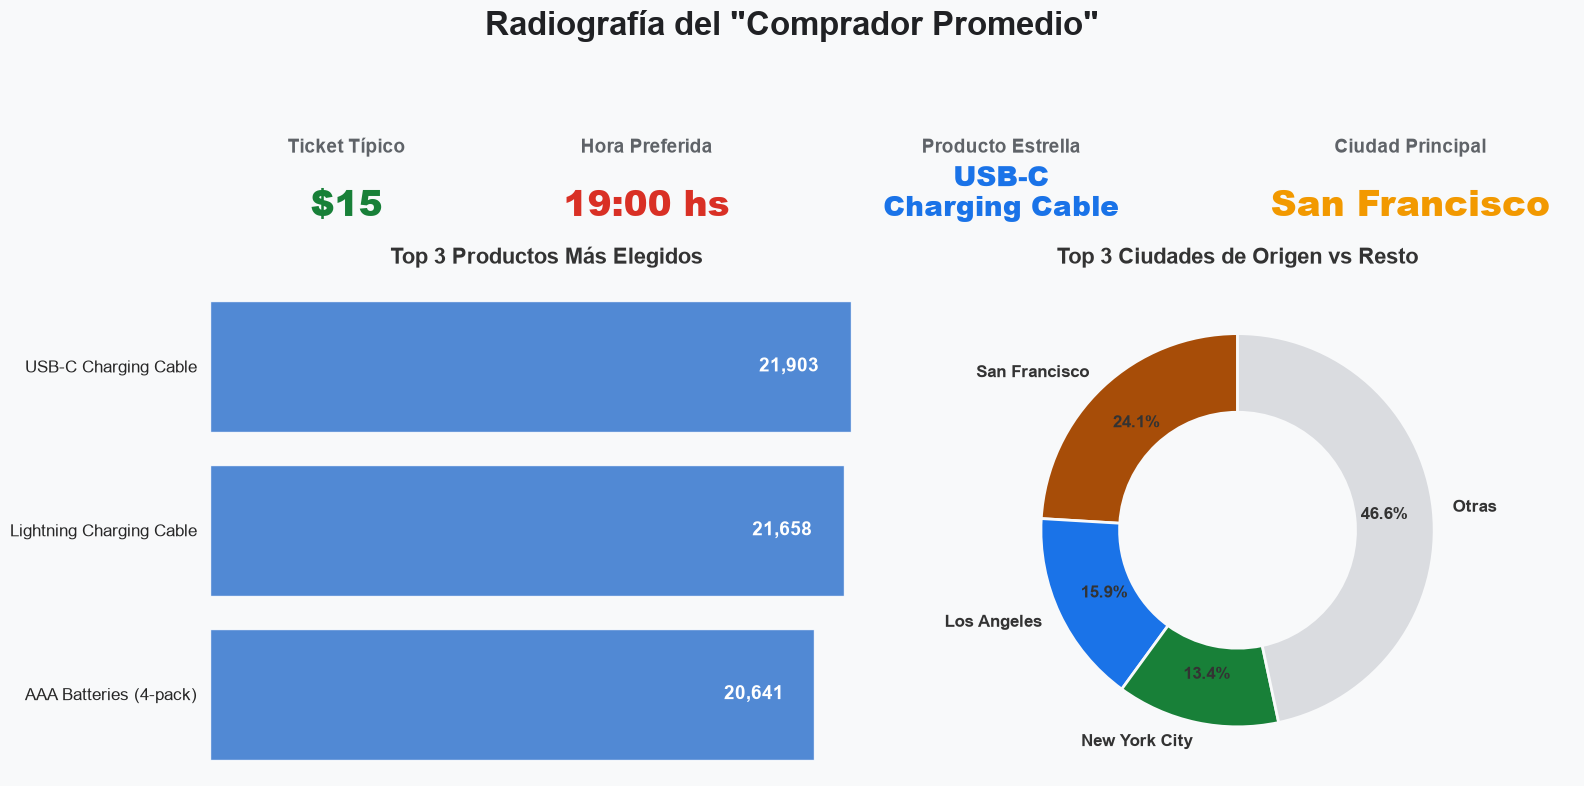

In [107]:
# Extraemos los valores más frecuentes (Moda) y la Mediana
ticket_tipico = df.groupby('ID de Pedido')['Venta'].sum().median()
producto_top = df['Producto'].value_counts().index[0]

# Prueba de tamaño de letras
if len(producto_top) > 15:
    producto_top = producto_top.replace(" ", "\n", 1) 

ciudad_top = df['Ciudad'].value_counts().index[0]
hora_top = df['Hora'].value_counts().index[0]


top3_productos = df['Producto'].value_counts().head(3)


todas_ciudades = df['Ciudad'].value_counts()
top3_ciudades = todas_ciudades.head(3)
otras_ciudades = todas_ciudades.iloc[3:].sum()

# Gráfico
valores_dona = list(top3_ciudades.values) + [otras_ciudades]
etiquetas_dona = list(top3_ciudades.index) + ['Otras']

# Dashboard: 
fig = plt.figure(figsize=(16, 8), facecolor='#F8F9FA') 
fig.suptitle('Radiografía del "Comprador Promedio"', fontsize=24, fontweight='bold', color='#202124', y=0.98)

# Panel superior para KPIs
ax_kpi = plt.subplot2grid((4, 2), (0, 0), colspan=2)
ax_kpi.axis('off')

# Ajustamos las posiciones en X para darle más espacio al Producto Estrella
kpis = [
    ("Ticket Típico", f"${ticket_tipico:.0f}", "#188038", 0.10),    
    ("Hora Preferida", f"{hora_top}:00 hs", "#d93025", 0.32),       
    ("Producto Estrella", producto_top, "#1a73e8", 0.58),           
    ("Ciudad Principal", ciudad_top, "#f29900", 0.88)              
]

for titulo, valor, color, x_pos in kpis:
    ax_kpi.text(x_pos, 0.6, titulo, fontsize=14, fontweight='bold', color='#5F6368', ha='center', transform=ax_kpi.transAxes)
    

    fuente_valor = 20 if "\n" in str(valor) else 26
    ax_kpi.text(x_pos, 0.1, valor, fontsize=fuente_valor, fontweight='black', color=color, ha='center', transform=ax_kpi.transAxes)

ax_kpi.plot([0.05, 0.95], [-0.1, -0.1], color='#DADCE0', lw=2, transform=ax_kpi.transAxes)

# Gráfico de Barras ocupando 3 filas
ax_bar = plt.subplot2grid((4, 2), (1, 0), rowspan=3)
sns.barplot(x=top3_productos.values, y=top3_productos.index, color="#1a73e8", ax=ax_bar, alpha=0.85)

ax_bar.set_title('Top 3 Productos Más Elegidos', fontsize=16, fontweight='bold', pad=15, color='#333333')
ax_bar.set_xlabel('')
ax_bar.set_ylabel('')
sns.despine(ax=ax_bar, left=True, bottom=True)
ax_bar.set_xticks([]) 
ax_bar.tick_params(axis='y', labelsize=12) 

for p in ax_bar.patches:
    x_pos = p.get_width() - (p.get_width() * 0.05)
    y_pos = p.get_y() + p.get_height() / 2
    ax_bar.annotate(f'{int(p.get_width()):,}', 
                    xy=(x_pos, y_pos), 
                    ha='right', va='center', color='white', fontweight='bold', fontsize=14)

# Gráfico de Torta 
ax_donut = plt.subplot2grid((4, 2), (1, 1), rowspan=3)


colores_dona = ["#a74d08", '#1a73e8', '#188038', '#DADCE0'] 

ax_donut.pie(
    valores_dona, 
    labels=etiquetas_dona, 
    colors=colores_dona, 
    autopct='%1.1f%%', 
    startangle=90, 
    pctdistance=0.75,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#333333'}, 
    wedgeprops=dict(width=0.4, edgecolor='#F8F9FA', linewidth=2) 
)

ax_donut.set_title('Top 3 Ciudades de Origen vs Resto', fontsize=16, fontweight='bold', pad=15, color='#333333')

# Ajustes finales
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Cantidad Pedida - Media y Mediana por transacción


In [118]:
pedidos_totales = df.groupby("ID de Pedido")[["Cantidad Pedida", "Venta"]].sum()

ticket_promedio_unidades = pedidos_totales["Cantidad Pedida"].mean()
ticket_promedio_ventas = pedidos_totales["Venta"].mean()

print(f"Unidades promedio por pedido completo: {ticket_promedio_unidades:.2f}")
print(f"Ticket promedio de venta (ingreso por pedido): ${ticket_promedio_ventas:.2f}")

Unidades promedio por pedido completo: 1.17
Ticket promedio de venta (ingreso por pedido): $193.30


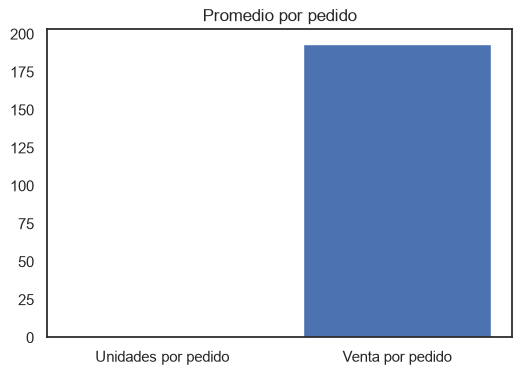

In [120]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Unidades por pedido", "Venta por pedido"],
    [ticket_promedio_unidades, ticket_promedio_ventas]
)
plt.title("Promedio por pedido")
plt.show()

In [119]:
media_diaria_ventas = df.groupby("Dia")["Venta"].sum().mean()
media_mensual_pedidos = df.groupby("Mes")["ID de Pedido"].nunique().mean()

print(f"Venta promedio por día: ${media_diaria_ventas:.2f}")
print(f"Cantidad promedio de pedidos por mes: {media_mensual_pedidos:.0f}")

Venta promedio por día: $1112646.32
Cantidad promedio de pedidos por mes: 14870


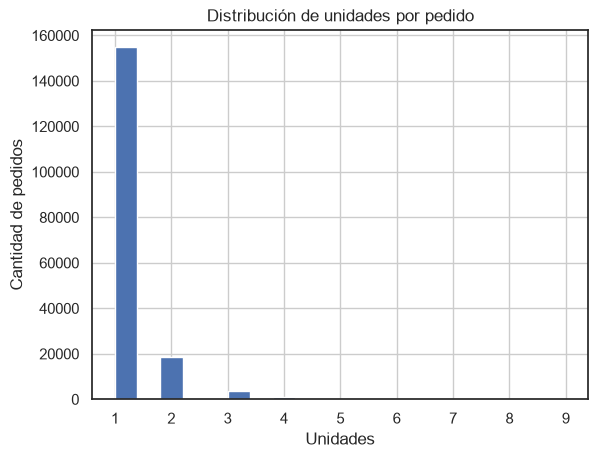

In [121]:
pedidos_totales["Cantidad Pedida"].hist(bins=20)
plt.title("Distribución de unidades por pedido")
plt.xlabel("Unidades")
plt.ylabel("Cantidad de pedidos")
plt.show()


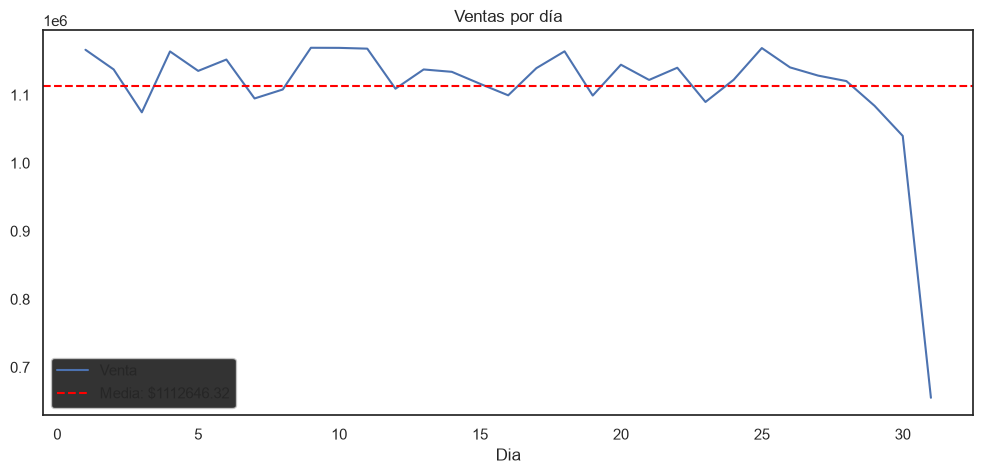

In [122]:
ventas_diarias = df.groupby("Dia")["Venta"].sum()

ventas_diarias.plot(figsize=(12,5))
plt.axhline(
    y=media_diaria_ventas,
    color="red",
    linestyle="--",
    label=f"Media: ${media_diaria_ventas:.2f}"
)

plt.title("Ventas por día")
plt.legend()
plt.show()


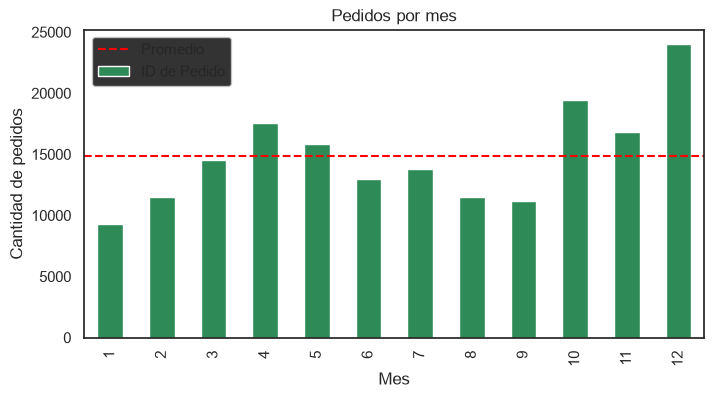

In [147]:
pedidos_mes = df.groupby("Mes")["ID de Pedido"].nunique()

pedidos_mes.plot(
    kind="bar",
    figsize=(8,4),
    color="seagreen"
)

plt.axhline(
    y=media_mensual_pedidos,
    color="red",
    linestyle="--",
    label="Promedio"
)

ax1.legend(
    lineas, etiquetas,
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='gray',
    framealpha=1.0
)
plt.title("Pedidos por mes")
plt.ylabel("Cantidad de pedidos")
plt.legend()
plt.show()

### Formulación de Hipótesis y Pruebas Estadísticas


Aplicamos la prueba no paramétrica de Mann-Whitney U para comparar el volumen de compra (cantidad de unidades pedidas) entre productos de bajo costo (Low-Ticket) y de alto costo (High-Ticket), usando la mediana del precio unitario como punto de corte entre ambos grupos.

$H_0$: la distribución de la cantidad pedida es idéntica entre productos de bajo y alto costo.
$H_1$: la distribución de la cantidad pedida difiere significativamente entre ambos grupos.





In [126]:
precio_mediano = df["Precio Unitario"].median()
grupo_low_ticket = df[df["Precio Unitario"] <= precio_mediano]["Cantidad Pedida"]
grupo_high_ticket = df[df["Precio Unitario"] > precio_mediano]["Cantidad Pedida"]

u_stat, u_p = stats.mannwhitneyu(grupo_low_ticket, grupo_high_ticket, alternative="two-sided")

print(f"Precio mediano usado como corte: ${precio_mediano:.2f}")
print(f"Cantidad pedida promedio (Low-Ticket):  {grupo_low_ticket.mean():.2f}")
print(f"Cantidad pedida promedio (High-Ticket): {grupo_high_ticket.mean():.2f}")
print(f"\nMann-Whitney U = {u_stat:.1f}, p-valor = {u_p:.4g}")

if u_p < 0.05:
    print("Resultado: se rechaza H0. Los clientes compran una cantidad de unidades distinta según el rango de precio del producto.")
else:
    print("Resultado: no se rechaza H0. No hay diferencia significativa en la cantidad pedida entre ambos grupos.")

Precio mediano usado como corte: $14.95
Cantidad pedida promedio (Low-Ticket):  1.22
Cantidad pedida promedio (High-Ticket): 1.00

Mann-Whitney U = 4945785591.5, p-valor = 0
Resultado: se rechaza H0. Los clientes compran una cantidad de unidades distinta según el rango de precio del producto.


## Media y Mediana por transacción
Puede verse general y por mes

In [109]:
# 1. Agrupar sumando las cantidades y ventas de cada pedido único
pedidos_totales = df.groupby("ID de Pedido")[["Cantidad Pedida", "Venta"]].sum()

# 2. Calcular la media de esos totales
ticket_promedio_unidades = pedidos_totales["Cantidad Pedida"].mean()
ticket_promedio_ventas = pedidos_totales["Venta"].mean()

print(f"Unidades promedio por pedido completo: {ticket_promedio_unidades:.2f}")
print(f"Ticket promedio de venta (ingreso por pedido): ${ticket_promedio_ventas:.2f}")

Unidades promedio por pedido completo: 1.17
Ticket promedio de venta (ingreso por pedido): $193.30


In [110]:
# Media diaria de ingresos
media_diaria_ventas = df.groupby("Dia")["Venta"].sum().mean()

# Media mensual de pedidos (contando IDs únicos)
media_mensual_pedidos = df.groupby("Mes")["ID de Pedido"].nunique().mean()

print(f"Venta promedio por día: ${media_diaria_ventas:.2f}")
print(f"Cantidad promedio de pedidos por mes: {media_mensual_pedidos:.0f}")

Venta promedio por día: $1112646.32
Cantidad promedio de pedidos por mes: 14870


### Creación de un perfil de buyer person

In [ ]:

# Preparar las métricas del Buyer Persona
# Geografía
ventas_ciudad = df.groupby('Ciudad')['Venta'].sum().sort_values(ascending=True)

# Comportamiento por Hora
ventas_hora = df.groupby('Hora')['Venta'].count()

# Comportamiento por Mes
meses_nombres = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun", 
                 7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}
df_mes = df.copy()
df_mes['Nombre_Mes'] = df_mes['Mes'].map(meses_nombres)
ventas_mes = df_mes.groupby('Mes')['Venta'].sum()
nombres_meses_ordenados = [meses_nombres[m] for m in ventas_mes.index]

# Preferencias de Producto
top_productos = df.groupby('Producto')['Cantidad Pedida'].sum().sort_values(ascending=True).tail(10)


top_compradores = df.groupby('Dirección de Envio').agg(
    Gasto_Total=('Venta', 'sum'),
    Productos_Comprados=('Cantidad Pedida', 'sum'),
    Cantidad_Pedidos=('ID de Pedido', 'nunique'),
    Ciudad=('Ciudad', 'first')
).sort_values(by='Gasto_Total', ascending=False).head(5).reset_index()

top_compradores['Gasto_Total'] = top_compradores['Gasto_Total'].apply(lambda x: f"${x:,.2f}")

# Creamos un identificador anónimo para proteger el perfil
top_compradores['ID Cliente (Oculto)'] = [f"Comprador Top {i+1}" for i in range(5)]

# Filtramos las columnas ordenadas, dejando fuera definitivamente 'Dirección de Envio'
top_compradores = top_compradores[['ID Cliente (Oculto)', 'Ciudad', 'Gasto_Total', 'Productos_Comprados', 'Cantidad_Pedidos']]


# Construir el Dashboard Interactivo con Subplots
fig = make_subplots(
    rows=3, cols=2,
    specs=[[{"type": "bar"}, {"type": "scatter"}],
           [{"type": "bar"}, {"type": "bar"}],
           [{"type": "table", "colspan": 2}, None]], # La tabla ocupa ambas columnas
    subplot_titles=("Ventas Totales por Ciudad (Ubicación)",
                    "Frecuencia de Compra por Hora (Hábitos)",
                    "Top 10 Productos Más Llevados",
                    "Evolución Anual de Ingresos (Estacionalidad)",
                    "Arquetipos Top 5: Mejores Clientes (Datos de Identidad Protegidos)"),
    vertical_spacing=0.12
)

# Gráfico de Ciudad
fig.add_trace(go.Bar(x=ventas_ciudad.values, y=ventas_ciudad.index, orientation='h', 
                     marker_color='#1E7EE4', name="Ciudad"), row=1, col=1)

# Gráfico de Hora
fig.add_trace(go.Scatter(x=ventas_hora.index, y=ventas_hora.values, mode='lines+markers', 
                         line=dict(color='#9E101E', width=3), name="Hora"), row=1, col=2)

# Gráfico de Productos
fig.add_trace(go.Bar(x=top_productos.values, y=top_productos.index, orientation='h', 
                     marker_color='#2ca02c', name="Productos"), row=2, col=1)

# Gráfico de Meses
fig.add_trace(go.Bar(x=nombres_meses_ordenados, y=ventas_mes.values, 
                     marker_color='#ff7f0e', name="Mes"), row=2, col=2)

# Top 5 Perfiles 
fig.add_trace(go.Table(
    header=dict(values=list(top_compradores.columns),
                fill_color='#333333',
                align='left', 
                font=dict(color='white', size=12, weight='bold')),
    cells=dict(values=[top_compradores[col] for col in top_compradores.columns],
               fill_color='#F4F4F4',
               align='left', 
               font=dict(color='#333333', size=11),
               height=30)
), row=3, col=1)


# Estilos generales del Dashboard
fig.update_layout(
    height=1000,
    width=1200,
    title_text="Dashboard Interactivo: Análisis del Buyer Persona y Clientes Principales",
    title_font=dict(size=22, family="Arial", color='#333333'),
    title_x=0.5,
    showlegend=False,
    plot_bgcolor='rgba(245,245,245,0.5)',
    paper_bgcolor='white',
    margin=dict(l=20, r=20, t=80, b=20)
)

fig.show()

# EXPORTAR A HTML
fig.write_html("dashboard_grupo2.html")
print("Dashboard seguro exportado exitosamente como 'dashboard_grupo2.html'!")

✅ ¡Dashboard seguro exportado exitosamente como 'dashboard_buyer_persona_protegido.html'!
